# Cubo Gelationoso
**Nome:** Ana Luiza de Lima Silva

**Disciplina:** Aprendizado de máquina - 2° semestre de 2026

**Professor responsável:** Daniel R. Cassar

----

## Sumário

1. [Introdução](#Introdução)
2. [Desenvolvimento](#Desenvolvimento)
   - [Importando bibliotecas](#Importando-bibliotecas)
   - [Importando o conjunto de dados](#Importando-o-conjunto-de-dados)
   - [Verificação e análise exploratória dos dados](#Verificação-e-análise-exploratória-dos-dados)
   - [Separando uma amostra dos dados para as análises](#Separando-uma-amostra-dos-dados-para-as-análises)
   - [Separação em dados de Treino e Teste](#Separação-em-dados-de-Treino-e-Teste)
   - [Algoritmo K-NN](#Algoritmo-K-NN)
     - [O modelo inicial](#O-modelo-inicial)
     - [Verificando a importância inicial de cada atributo](#Verificando-a-importância-inicial-de-cada-atributo)
     - [Variando o número de vizinhos e avaliando as métricas](#Variando-o-número-de-vizinhos-e-avaliando-as-métricas)
     - [Variando a função de distância e avaliando as métricas](#Variando-a-função-de-distância-e-avaliando-as-métricas)
     - [Variando os conjuntos de hiperparâmetros](#Variando-os-conjuntos-de-hiperparâmetros)
     - [Versão do KNN final com a melhor acurácia](#Versão-do-KNN-final-com-a-melhor-acurácia)
     - [Avaliando a importância final de cada atributo](#Avaliando-a-importância-final-de-cada-atributo)
   - [Normalizando os dados e avaliando o algoritmo KNN](#Normalizando-os-dados-e-avaliando-o-algoritmo-KNN)
     - [Normalização usando o normalizador padrão "Standard-scaler"](#Normalização-usando-o-normalizador-padrão-Standard-scaler)
     - [Normalização pelo máximo absoluto usando "MaxAbsScaler"](#Normalização-pelo-máximo-absoluto-usando-MaxAbsScaler)
     - [Normalização pelo mínimo e máximo usando "MinMaxScaler"](#Normalização-pelo-mínimo-e-máximo-usando-MinMaxScaler)
     - [Comparando as normalizações](#Comparando-as-normalizações)
   - [Teste de hipótese 1 - Codificar alguns dos atributos alteraria o resultado?](#Teste-de-hipótese-1---Codificar-alguns-dos-atributos-alteraria-o-resultado)
   - [Teste de hipótese 2 - Qual seria o resultado de um modelo que normaliza e codifica os dados?](#Teste-de-hipótese-2---Qual-seria-o-resultado-de-um-modelo-que-normaliza-e-codifica-os-dados)
   - [Avaliação do modelo baseline](#Avaliação-do-modelo-baseline)
   - [Quais os resultados de diferentes métricas de desempenho?](#Quais-os-resultados-de-diferentes-métricas-de-desempenho)
     - [Gerando a curva de comparação de AUC-ROC entre o KNN de melhor resultado e o Baseline](#Gerando-a-curva-de-comparação-de-AUC-ROC-entre-o-KNN-de-melhor-resultado-e-o-Baseline)
3. [Conclusões e principais aprendizados](#Conclusões-e-principais-aprendizados)
4. [Uso de IA neste projeto](#Uso-de-IA-neste-projeto)
5. [Referências](#Referências)

----

## Introdução

O Aprendizado de Máquina é a subárea da Inteligência Artificial responsável por construir e avaliar modelos (ou algoritmos) capazes de aprender padrões de comportamento a partir dos dados com que são treinados, de modo a realizar previsões e tomar decisões compatíveis com suas observações. Dentre suas muitas subdivisões, encontra-se o aprendizado supervisionado, em que os modelos recebem atributos (features) e devem prever alvos (targets), sendo essa a área que será abordada no decorrer deste notebook. [1]

Para sua construção, será utilizado o modelo KNN (k-vizinhos mais próximos), o qual se baseia na ideia de que observações com características semelhantes encontram-se mais próximas no espaço e tendem à pertencer à mesma classe. Desse modo, sua classificação considera que, para cada nova observação a ser classificada, são separados seus k vizinhos mais próximos, sendo a classe mais frequente entre eles atribuída como a classe da observação. Com isso, nota-se que este modelo é sensível tanto à quantidade k de vizinhos escolhida quanto à função de distância, o que será desenvolvido em etapas subsequentes do notebook. [2]

Para o treinamento desse modelo, utilizaremos a estratégia de Holdout, separando os dados do Dataset escolhido entre amostras para treino, visualizadas pelo modelo durante sua construção, e teste, utilizadas para verificar a capacidade do modelo de prevê-las corretamente ou não. [3] Em seguida, para a visualização do desempenho desse modelo, utilizaremos as métricas de Acurácia, que mede o a relação entre as previsões corretas realizadas pelo modelo, e o F1-score, cujo objetivo é balancear as observações de Falsos Positivos e Negativos registradas pelo modelo, sendo a segunda mais adequada a dados desbalanceados como a Dataset escolhido, o que será discutido e investigado ao longo da atividade. [4]

O notebook desenvolvido a seguir se trata da primeira entrega da disciplina de Aprendizado de Máquina, o mostro lendário Cubo Gelatinoso, ministrada pelo professor Dr. Daniel Roberto Cassar durante o segundo semestre de 2026. O objetivo dessa atividade é permitir um primeiro contato dos estudantes com modelos de Aprendizado de Máquina, em especial o KNN, de modo a visualizar o desempenho e comportamento deste. Para seu desenvolvimento, foi escolhido o Dataset "CDC Diabetes Health Indicators", do repositório ICI Machine Learning. [5] O repositório escolhido investiga a presença ou não de diabetes na população considerada para o estudo a partir de seus indicadores de saúde, de modo que seu target é um dado categórico (ou qualitativo) binário, de modo que este será um problema de classificação para o qual serão consideradas quantidades k de vizinhos ímpares.

Para complementar a implementação do modelo KNN, serão avaliados diferentes conjuntos de hiperparâmetros e estratégias de normalização e codificação de modo a investigar como essas afetam o comportamento do modelo. Ademais, como análise adicional, o modelo será comparado a um Baseline para verificar e discutir qual desses se adequa e é capaz de prever melhor as observações do Dataset.

----

## Desenvolvimento

A seção apresentada a seguir, desenvolvida em subseções explicadas individualmente conforme o objetivo de cada uma delas, se desbruça sobre o desenvolvimento da atividade, apresentando a importação e avaliação do dataset e treinamento e avaliação dos modelos de aprendizado de máquina.

### Importando bibliotecas

Nesta seção inicial, são importadas as bibliotecas utilizadas durante o desenvolvimento de todo o notebook. O uso de cada uma delas foi:
- Pandas: utilizada para a visualização e manipulação dos dados em DataFrames; 

- Seaborn: utilizada para a produção dos gráficos presentes no notebook;

- Matplotlib.pyplot: utilizada para melhorar a visualização de alguns dos gráficos;

- O objeto "permutation_importance" da biblioteca Sklearn.inspection: utilizado para avaliar a importância de cada um dos atributos utilizados para o modelo;

- O objeto "train_test_split" da biblioteca Sklearn.model_selection: utilizado para realizar a divisão dos dados de treino e teste antes de efetivamente instanciar e treinar o modelo;

- O objeto "KNeighborsClassifier" da biblioteca Sklearn.neighbors: utilizado para implementar o algoritmo KNN; [6]

- O objeto "DummyClassifier" da biblioteca Sklearn.dummy: utilizado para treinar o modelo de Baseline;

- O objeto "product" da bilioteca itertools: utilizado para realizar a variação dos conjuntos de hiperparâmetros apra avaliar o modelo KNN;

- Os objetos "accuracy_score", "confusion_matrix", "roc_auc_score", "precision_score", "recall_score", "f1_score", "roc_curve" da biblioteca Sklean.metrics: utilizados para comparar os resultados de diferentes métricas de desempenho. Cada um deles será explicado em detalhes na seção "Quais os resultados de diferentes métricas de desempenho?; [7]

- Os objetos "StandardScaler", "MaxAbsScaler", "MinMaxScaler", "OneHotEncoder" da biblioteca Sklearn.preprocessing: utilizados na normalização e codificação dos dados. Serão explicados nas seções "Normalizando os dados e avaliando o algoritmo KNN", "Teste de hipótese - codificar os atributos alteraria os resultados?" e "Qual seria o resultado ao codificar e normalizar os dados?". [8]

In [110]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

from itertools import product
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler, OneHotEncoder


### Importando o conjunto de dados

Como já apresentado na seção de introdução, o conjunto de dados escolhidos para as análises foi proveniente do repositório UCI Machine Learning, correspondendo ao Dataset intitulado "CDC Diabetes Health Indicators". A seção desenvolvida a seguir apresenta o próprio código de importação proposto pelo site e sua biblioteca oficial, sem haver a necessidade de instalar diretamente o dataset.

In [111]:
# instalando a biblioteca que contém os repositórios da UCI
!pip install ucimlrepo


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [112]:
from ucimlrepo import fetch_ucirepo 
  
# importando o dataset escolhido
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# código padrão informado pela UCI para importação do dataset sob a forma de DataFrame
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

print(cdc_diabetes_health_indicators.metadata) 
  
print(cdc_diabetes_health_indicators.variables) 

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [113]:
# verificando o conjunto de dados em um único DataFrame
dados = pd.concat([X, y], axis=1)
dados

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,0,3,0,5,0,1,5,6,7,0
253676,1,1,1,18,0,0,0,0,0,0,...,0,4,0,0,1,0,11,2,4,1
253677,0,0,1,28,0,0,0,1,1,0,...,0,1,0,0,0,0,2,5,2,0
253678,1,0,1,23,0,0,0,0,1,1,...,0,3,0,0,0,1,7,5,1,0


Observando o DataFrame final, temos que ele é formado por 253679 dados e 22 atributos ('HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker' 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 
'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income' e 'Diabetes_binary'), superando o que foi solicitado pela atividade.

Convém ressaltar que todos os dados já são previamente tratados pela própria base de dados, de modo que os atributos não precisam ser codificados.

### Verificação e análise exploratória dos dados

A seção a seguir se dedica a avaliar todos os dados do Datasetm verificando sua frequência, parâmetros estatísticos, distribuições entre as classes de diabéticos e não-diabéticos e das correlações entre os atributos e o target.

In [114]:
# gerando as estatísticas descritivas para o dataset
dados.describe(include="all")

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


Realizando a verificação dos dados, é possível notar que não existem valores nulos ou não informados ("NaN"), de modo que não é necessário um pré-processamento que os retire. Ademais, quanto à classificação dos dados, nota-se que apenas um dos atributos, 'BMI', é um dado numérico (ou quantitativo) contínuo; dois são variáveis numéricas discretas, 'MentHlth' e 'PhysHIth'; quatro são dados categóricos (ou qualitativos) ordinais, 'GenHIth', 'Age', 'Education' e 'Income'; enquanto as demais, incluindo o target 'Diabetes_binary', são variáveis binárias.

Todos esses dados já se apresentam codificados numericamente no próprio Dataset, o que não significa que, na realidade, esses sejam dados numéricos e/ou quantitativos. No entanto, em se tratando de um modelo que avalia a distância entre os dados, tal codificação é importante para assegurar seu funcionamento correto, além de simplificar a implementação durante o notebook.

Ao avaliar a tabela descritiva do Dataframe gerada anteriormente, é possível notar que os únicos atributos para os quais as medidas de média e desvio padrão são coerentes são 'MentHlth' e 'PhysHlth', uma vez que as demais variáveis numéricas expressam apenas faixas com categorias definidas. Com isso, temos que, em média, durante três dias no último mês os indivíduos avaliados atribuíram que sua saúde mental não estava boa, havendo ao menos um deles que deu a máxima resposta possível de 30 dias. Já para a a saúde física, em média, durante 4 dias ela foi atribuída pelos participantes como não estando boa, mais uma vez havendo pelo menos um deles que deu a resposta máxima de 30 dias.

Enquanto isso, para os dados binários, a média permite identificar qual porcentagem dos entrevistados apresenta determinada condição. Por exemplo, para 'HighBP', temos que, aproximadamente, 0.43, ou seja, 43% deles apresenta pressão alta, enquanto, de acordo com 'CholChek', cerca de 96% deles registrou altos índices de colesterou durante os últimos 5 anos.

Text(0.5, 1.0, 'Distribuição das classes no conjunto de dados')

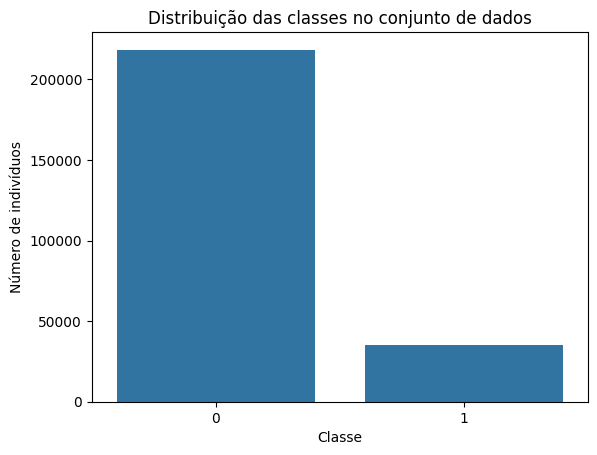

In [115]:
# verificando a relação entre a quantidade de diabéticos e não-diabéticos
contagem_classes = dados["Diabetes_binary"].value_counts().sort_index()

# gerando um gráfico de barras de comparação entre as classes
ax = sns.barplot(
    x=contagem_classes.index,
    y=contagem_classes.values
)

ax.set_xlabel("Classe")
ax.set_ylabel("Número de indivíduos")
ax.set_title("Distribuição das classes no conjunto de dados")

In [116]:
# verificando a distribuição das classes
contagem_classes = dados["Diabetes_binary"].value_counts().sort_index()
porcentagem_classes = dados["Diabetes_binary"].value_counts(
    normalize=True
).sort_index() * 100

# criando uma tabela com quantidade e porcentagem
distribuicao_classes = pd.DataFrame({
    "Quantidade": contagem_classes,
    "Porcentagem": porcentagem_classes
})

distribuicao_classes

,Quantidade,Porcentagem
Diabetes_binary,,
0,218334,86.066698
1,35346,13.933302


Avaliando a distribuição dos indivíduos avaliados por esse Dataset entre as classes 0 (não apresenta diabetes) e 1 (é diabético ou pré-diabético), temos que, aproximadamente, 86% deles se enquadra à primeira categoria, enquanto apenas 14% à segunda. Com isso, temos que esse se trata de um conjunto de dados desbalanceado, o que irá guiar as análises realizadas a seguir e influenciar os resultados para as métricas de desempenho, mas essas são cenas para as próximas seções ;)

In [117]:
# avaliando a correlação entre os atributos e o target
correlacao_target = abs(dados.corr(numeric_only=True)["Diabetes_binary"]).sort_values(ascending=False)
correlacao_target

Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Income                  0.163919
Education               0.124456
PhysActivity            0.118133
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
HvyAlcoholConsump       0.057056
Veggies                 0.056584
Fruits                  0.040779
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Name: Diabetes_binary, dtype: float64

Text(0.5, 1.0, 'Correlação entre todos os atributos e o target (apresentar diabetes)')

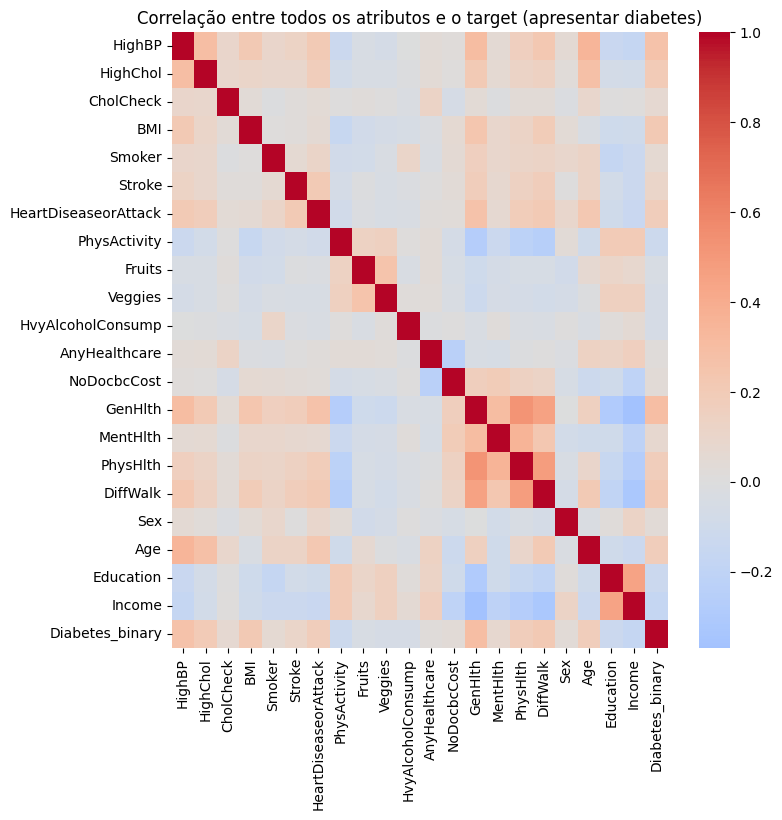

In [118]:
# gerando um heatmap com as correlações entre os atributos e o target
plt.figure(figsize=(8, 8))
sns.heatmap(dados.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlação entre todos os atributos e o target (apresentar diabetes)")

Ao avaliar a correlação de Pearson entre os atributos e o target, a qual pode ser observada a partir da matriz de correlação apresentada acima, podemos obter que o atributo mais correlacionado à presença de diabetes é 'GenHlth", ou seja, a categoria que os entrevistados atribuem à própria saúde, indo de excelente à péssima, com cerca de 30% de correlação. Enquanto isso, 'AnyHealthcare', é aquela que apresenta a menor correlação, com cerca de 0.5%, indicando que a o fato de os indíviduos possuírem ou não plano de saúde apresenta pouca ou nenhuma correlação com o fato de esses apresentarem diabetes.

### Separando uma amostra dos dados para as análises

Dado o grande volume de dados do Dataset escolhido, a fim de facilitar e tornar mais fluída a execução do notebook e a avaliação dos resultados nas etapas a seguir, optou-se por selecionar apenas uma pequena amostra dos dados, contendo 5000 observações. Para isso, utilizou-se o mesmo mecanismo empregado para a separação entre os dados de treino e teste como uma alternativa para manter o desbalanceamente registrado pelos dados, inserindo o objeto "stratify" à separação para assegurar essa ocorrrência.

In [119]:
# definindo uma semente aleatória para garantir a reprodutibilidade dos resultados
SEMENTE_ALEATORIA = 87430

# separando apenas uma amostra do conjunto de dados

dados, _ = train_test_split(
    dados,
    train_size=5000,
    random_state=SEMENTE_ALEATORIA,
    stratify=dados['Diabetes_binary']
)

dados = dados.reset_index(drop=True)

In [120]:
dados.describe(include="all")

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,0.435200,0.430000,0.961800,28.394800,0.439600,0.042000,0.097400,0.756800,0.627600,0.820600,...,0.084600,2.522200,3.298600,4.406400,0.169800,0.427400,8.029000,5.04760,5.976400,0.139400
std,0.495833,0.495125,0.191698,6.850834,0.496388,0.200609,0.296531,0.429058,0.483492,0.383725,...,0.278313,1.063265,7.576181,8.899476,0.375495,0.494751,3.046837,0.98302,2.085357,0.346398
min,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.00000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.00000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.00000,8.000000,0.000000
max,1.000000,1.000000,1.000000,89.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.00000,8.000000,1.000000


Avaliando a descrição geral da amostra considerada para as análises posteriores realizadas durante o notebook, temos que agora todos os atributos passam a contar com 5000 observações. No entanto, isso não altera o modo como os classificamos anteriormente, bem como apresenta pouca variação sobre as médias e máximos registrados pelos atributos 'GenHlth' e 'MentHlth'.

Text(0.5, 1.0, 'Distribuição das classes no conjunto de dados')

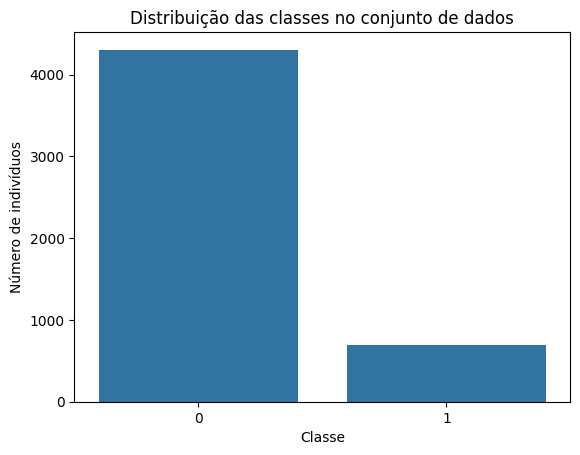

In [121]:
# verificando a relação entre a quantidade de diabéticos e não-diabéticos
contagem_classes = dados["Diabetes_binary"].value_counts().sort_index()

# gerando um gráfico de barras de comparação entre as classes
ax = sns.barplot(
    x=contagem_classes.index,
    y=contagem_classes.values
)

ax.set_xlabel("Classe")
ax.set_ylabel("Número de indivíduos")
ax.set_title("Distribuição das classes no conjunto de dados")

In [122]:
# verificando a distribuição das classes após a amostragem
contagem_classes_amostra = dados["Diabetes_binary"].value_counts().sort_index()
porcentagem_classes_amostra = (
    dados["Diabetes_binary"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

distribuicao_classes_amostra = pd.DataFrame({
    "Quantidade": contagem_classes_amostra,
    "Porcentagem": porcentagem_classes_amostra
})

distribuicao_classes_amostra

,Quantidade,Porcentagem
Diabetes_binary,,
0,4303,86.06
1,697,13.94


Passando a verificar agora a relação entre as classes 0 (não-diabético) e 1 (diabético ou pré-diabético) na amostra selecionada, podemos notar que essa relação continua sendo de, aproximadamente, 86% para 14%, respectivamente. Ou seja, conforme o esperado, a estratégia empregada manteve o desbalanceamento entre os dados a serem avaliados a seguir.

### Separação em dados de Treino e Teste

Esta seção se dedica a implementar a estratégia de holdout, separando 15% dos dados como dados de teste para avaliar o desempenho do modelo e o restante, 85%, para treinar o modelo. Assim, busca-se realizar uma simulação real do uso do modelo, aplicando-o a dados que ele não visualizou durante seu treinamento.

Para garantir a reprodutibilidade dos resultados e sorteios obtidos, foi mantida a mesma semente aleatória já definida anteriormente. Além disso, o objeto 'stratify' continuou sendo utilizado nessa etapa, assim como foi na anterior, paa garantir a manutenção do desbalanceamente entre as classes de diabéticos e não-diabéticos.

In [123]:
# separando 15% dos dados para testar o modelo
TAMANHO_TESTE = 0.15

# separando treino e teste a partir dos índices do DataFrame do dataset
indices = dados.index
indices_treino, indices_teste = train_test_split(indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA, stratify=dados['Diabetes_binary'])

# separando os dados de treino e teste a partir dos índices sorteados
dados_treino = dados.loc[indices_treino]
dados_teste = dados.loc[indices_teste]

In [124]:
# visualizando os dados de treino
print("DataFrame com o conjunto de dados para treino do modelo")
dados_treino

DataFrame com o conjunto de dados para treino do modelo


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
41,1,0,1,25,0,0,0,1,1,1,...,0,2,0,0,0,0,9,6,7,0
2932,1,1,1,29,0,0,0,1,1,1,...,0,4,0,0,1,0,13,4,5,1
2624,1,0,1,29,0,0,0,1,1,1,...,0,1,0,0,0,1,10,5,7,0
2379,0,0,1,23,0,0,0,1,1,1,...,0,1,0,0,0,1,5,6,8,0
1185,0,1,1,26,0,0,0,1,1,1,...,0,2,3,1,0,0,1,6,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2033,0,0,1,17,1,0,0,1,1,0,...,0,1,0,0,0,0,10,4,5,0
587,0,0,1,24,1,0,1,1,1,1,...,1,1,2,0,0,1,11,5,3,0
4673,0,0,1,27,0,0,0,1,0,1,...,0,1,0,0,0,0,5,6,8,0
446,1,1,1,25,1,1,0,1,0,1,...,0,4,30,30,0,0,9,5,3,0


In [125]:
# visualizando os dados de teste
print("DataFrame com o conjunto de dados para teste do modelo")
dados_teste

DataFrame com o conjunto de dados para teste do modelo


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
4150,0,0,1,27,1,0,0,1,0,1,...,0,2,0,0,0,0,2,6,8,0
4833,1,1,1,28,0,0,0,1,0,1,...,0,3,5,0,0,0,9,6,8,0
2623,0,0,1,22,0,0,0,1,1,1,...,0,2,0,0,0,0,10,6,6,0
185,1,1,1,31,1,0,0,1,0,1,...,0,3,0,1,0,0,6,6,4,1
2896,1,1,1,25,1,0,1,1,0,0,...,0,1,7,0,0,0,9,6,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0,0,1,24,0,0,0,1,1,1,...,1,2,4,10,0,1,7,6,8,0
981,0,1,1,28,0,0,0,0,0,1,...,0,1,0,0,0,1,11,4,6,0
3059,1,1,1,27,0,0,0,1,1,1,...,1,3,0,7,0,0,9,6,3,1
3560,1,0,1,28,1,0,0,1,1,1,...,0,3,0,5,0,0,7,5,8,1


In [126]:
# verificando a proporção entre os tipos de dados em cada amostra
print("Proporção na amostra avaliada:")
print(dados['Diabetes_binary'].value_counts(normalize=True))
print()

print("Proporção no treino:")
print(dados_treino['Diabetes_binary'].value_counts(normalize=True))
print()

print("Proporção no teste:")
print(dados_teste['Diabetes_binary'].value_counts(normalize=True))
print()

Proporção na amostra avaliada:
Diabetes_binary
0    0.8606
1    0.1394
Name: proportion, dtype: float64

Proporção no treino:
Diabetes_binary
0    0.860706
1    0.139294
Name: proportion, dtype: float64

Proporção no teste:
Diabetes_binary
0    0.86
1    0.14
Name: proportion, dtype: float64



Ao verificar as proporções entre as classes 0 (não-diabéticos) e 1 (diabéticos e pré-diabéticos) na amostra selecionada do Dataframe e nas seleções para treino e teste, observa-se que, em todos eles, essa é de, aproximadamente, 86% para 14%, garantindo resultados que reflitam o desbalanceamento do conjunto de dados.

### Algoritmo K-NN

A partir dessa seção será efetivamente implementado o modelo K-vizinhos mais próximos. Cada uma das seções divide-se conforme um objetivo próprio, especificado por cada uma delas.

#### O modelo inicial

Inicialmente, será implementado um modelo de KNN "simples", sem avaliar qual seriam as condições que melhoram seu desempenho e escolhendo arbitrariamente um número de vizinhos. Nesse caso, foram escolhidos 21 vizinhos, laém de serem atribuídos os atributos e o target utilizados durante todo o restante do notebook.

Note que o número de vizinhos escolhido é ímpar, assim como todos os que serão avaliados a seguir. Isso ocorre pois, se tratando de um target binário, a escolha de um número par poderia favorecer que o empate entre as duas classes, fazendo com que o modelo escolhesse aleatoriamente entre elas. Desse modo, a escolha de números ímpares se dá para evitar essa ocorência.

In [127]:
# verificando os nomes das colunas do conjunto de dados
print(dados.columns)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='object')


In [128]:
# definindo os atributos e target do modelo a partir do nome das colunas
ATRIBUTOS = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 
'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 
'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

TARGET = ['Diabetes_binary']

In [129]:
# coletando atributos e targets dos dados de treino e teste
X_treino = dados_treino.reindex(ATRIBUTOS, axis=1)
y_treino = dados_treino.reindex(TARGET, axis=1).values.ravel()

X_teste = dados_teste.reindex(ATRIBUTOS, axis=1)
y_teste = dados_teste.reindex(TARGET, axis=1).values.ravel()

In [130]:
# instanciando o modelo
NUM_VIZINHOS = 21
modelo_knn = KNeighborsClassifier(n_neighbors=NUM_VIZINHOS)

In [131]:
# treinando o modelo com os dados de treino
modelo_knn.fit(X_treino, y_treino)

,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [132]:
# definindo a ordem das colunas para a matriz de confusão
ordem_labels = [0, 1]

[Text(0, 0.5, 'Não-diabético'), Text(0, 1.5, 'Diabético')]

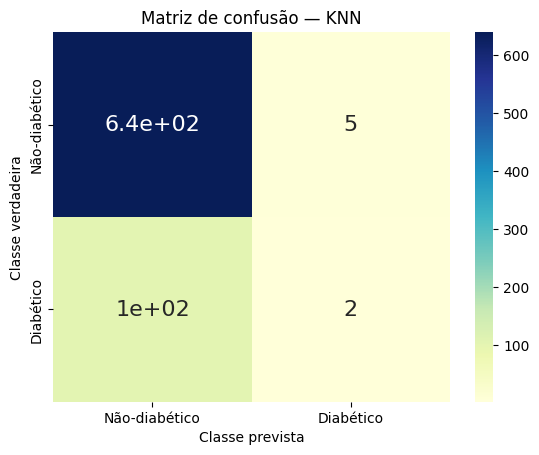

In [133]:
# exibindo a matriz de confusão como um heatmap
y_verdadeiro = y_teste
y_previsao = modelo_knn.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

matriz_conf = sns.heatmap(df_conf, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")

# atribuindo nomes aos eixos da matriz de confusão
matriz_conf.set_xlabel("Classe prevista")
matriz_conf.set_ylabel("Classe verdadeira")
matriz_conf.set_title("Matriz de confusão — KNN")

matriz_conf.set_xticklabels(["Não-diabético", "Diabético"])
matriz_conf.set_yticklabels(["Não-diabético", "Diabético"])

In [134]:
# verificando a acurácia e F1_scorepara o KNN
acuracia = accuracy_score(y_verdadeiro, y_previsao)
f1 = f1_score(y_verdadeiro, y_previsao)

print(f"Acurácia = {(acuracia*100):.2f}%")
print(f"F1_score = {f1*100:.2f}%")

Acurácia = 85.60%
F1_score = 3.57%


Observando a matriz de confusão e as métricas de desempenho obtidas para o modelo KNN inicial, temos que a maior parte dos dados foi classificada corretamente, ou seja, foram verdadeiros positivos e verdadeiros negativos. No entanto, para 5 dos indivíduos da amostra o modelo previu um Falso Positivo, e para 100 um Falso Negativo, sendo esse o registro que gera maior preocupação.

Se tratanto de um contexto de saúde, ambos os casos de previsão falsa são preocupantes, uma vez que pessoas sem diabetes podem adotar tratamentos que não deveriam, enquanto aquelas que realmente possuem a doença podem permanecer ignorantes sobre sua condição.

A partir da acurácia, ou seja, da relação previsões corretas e o total delas que foram realizadas, temos que essa foi de 85.6%, ou seja, uma métrica satisfatória e relativamente alta. Enquanto isso, o F1-score, que avalia tanto a precisão quanto recordação (recall) do modelo, foi relativamente baixo, com 3.57%. Isso demonstra que o modelo não faz uma ótima previsão tanto para diabéticos quanto para não-diabéticos, o que possivelmente é resultado do desbalanceamento existente entre os dados.

#### Verificando a importância inicial de cada atributo

Esta seção se dedica a avaliar a importância de cada um dos atributos para a construção do algoritmo KNN implementado na seção anterior. Para isso, os atributos são embaralhados 20 vezes entre si, de modo a avaliar como essa ordem afeta a medida de F1-score registrada pelo modelo. Com isso, se o embaralhamento piorar essa métrica de desempenho, isso significa que essa era uma métrica importante para o modelo, caso contrário, esse é um atributo de pouca importância.

C:\Users\ana2610001\AppData\Local\Temp\ipykernel_25276\3006528718.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  eixo.set_xticklabels(eixo.get_xticklabels(), rotation=90);


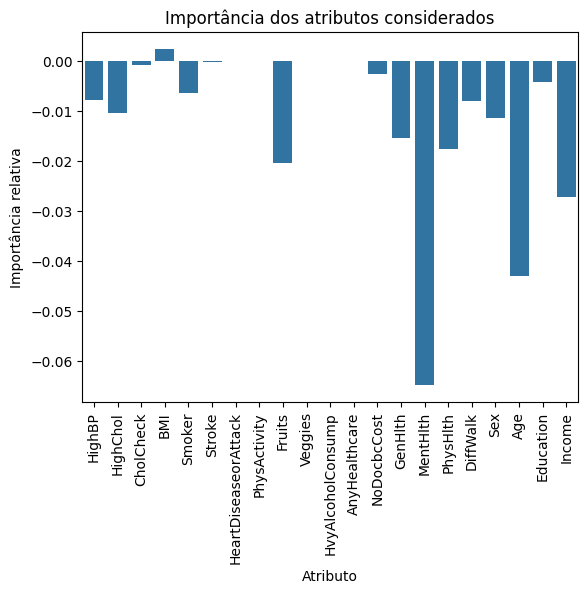

In [135]:
# definindo quantas vezes a ordem dos atributos será alterada
N_EMBARALHAMENTOS = 20

# calculando a importância de cada atributo por meio da permutação
resultado_importancia = permutation_importance(
    modelo_knn,
    X_teste,
    y_teste,
    n_repeats=N_EMBARALHAMENTOS,
    random_state=SEMENTE_ALEATORIA,
    scoring="f1",
)

# obtêm a importância média de cada atributo após os embaralhamentos
importancia = resultado_importancia.importances_mean

# plotando a importância de cada atributo em um gráfico de barras
eixo = sns.barplot(x=ATRIBUTOS, y=importancia)
eixo.set_ylabel("Importância relativa")
eixo.set_xlabel("Atributo")
eixo.set_title("Importância dos atributos considerados")
eixo.set_xticklabels(eixo.get_xticklabels(), rotation=90);

Ao obervar o gráfico produzido para visualizar a importância relativa de cada um dos atributos, temos que 'BMI', ou seja, o índice de massa corporal dos indivíduos avaliados pela amostra, é aquele que mais influencia o modelo, sendo um atributo importante. Enquanto isso, atributos como 'HeartDiseaseorAttack', 'PhysActivity', 'Veggies' e outros apresentaram importância relativa igual ou próxima a zero, indicando que esses não são atributos muito relevantes para o modelo. Por fim, registros negativos, como foi o caso de 'MentHlth' e 'Age', resultaram na melhoria do desempenho do modelo, mesmo que isso não indique uma correlação real com o target avaliado.

Convém notar que esses registros diferem dos registros presentes na matriz de correlação da seção de "Verificação e análise exploratória dos dados", evidenciando que o coeficiente de correlação de Pearson reconheceu apenas as relações lineares existentes entre a presença de diabetes e o atributo 'GenHlth', enquanto o "permutation_importance" pode ter observado relações que não são de natureza linear, mas ainda assim existem, entre a presença de diabetes e o atributo 'BMI'.

#### Variando o número de vizinhos e avaliando as métricas

Nesta seção, é avaliado como a variação do número de vizinhos influencia e altera os resultados das métricas de desempenho do modelo KNN. Com isso, podemos obervar os seguintes resultados e representação gráfica:

A acurácia do modelo KNN usando n_neighbors = 3 foi de 81.60%,
 enquanto o F1_score foi de 21.59%.
A acurácia do modelo KNN usando n_neighbors = 7 foi de 85.60%,
 enquanto o F1_score foi de 22.86%.
A acurácia do modelo KNN usando n_neighbors = 11 foi de 86.00%,
 enquanto o F1_score foi de 14.63%.
A acurácia do modelo KNN usando n_neighbors = 15 foi de 85.47%,
 enquanto o F1_score foi de 8.40%.
A acurácia do modelo KNN usando n_neighbors = 19 foi de 85.73%,
 enquanto o F1_score foi de 6.96%.
A acurácia do modelo KNN usando n_neighbors = 21 foi de 85.60%,
 enquanto o F1_score foi de 3.57%.
A acurácia do modelo KNN usando n_neighbors = 25 foi de 85.87%,
 enquanto o F1_score foi de 5.36%.
A acurácia do modelo KNN usando n_neighbors = 29 foi de 86.00%,
 enquanto o F1_score foi de 7.08%.
A acurácia do modelo KNN usando n_neighbors = 31 foi de 85.87%,
 enquanto o F1_score foi de 5.36%.


Text(0.5, 1.0, 'Acurácia do K-NN em função de k')

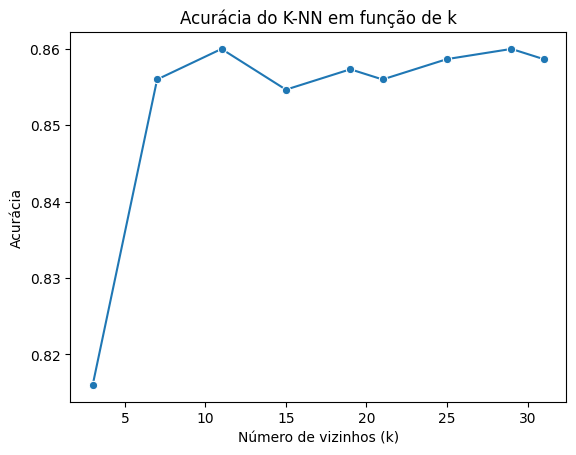

In [136]:
# lista que armazena os números de vizinhos testados
NUM_VIZINHOS = [3, 7, 11, 15, 19, 21, 25, 29, 31]

# lista que armazena o resultado da acurácia para cada número de vizinhos
resultado_vizinhos = []

# laço de repetição para testar o KNN com diferentes números de vizinhos
for n_vizinho in NUM_VIZINHOS:

    # instanciando o modelo
    modelo_knn = KNeighborsClassifier(n_neighbors=n_vizinho)

    # treinando o modelo
    modelo_knn.fit(X_treino, y_treino)

    # obtendo a acurácia
    y_verdadeiro = y_teste
    y_previsao = modelo_knn.predict(X_teste)
    acuracia = accuracy_score(y_verdadeiro, y_previsao)
    f1 = f1_score(y_verdadeiro, y_previsao)

    # adicionando os resultados da acurácia conforme o número de vizinhos
    resultado_vizinhos.append({"número de vizinhos": n_vizinho, "acuracia": acuracia, "F1-score": f1})

    print(f"A acurácia do modelo KNN usando n_neighbors = {n_vizinho} foi de {acuracia*100:.2f}%,")
    print(f" enquanto o F1_score foi de {f1*100:.2f}%.")
    
df_varia_vizinhos = pd.DataFrame(resultado_vizinhos)

# gráfico para visualização da progressão da acurácia
ax = sns.lineplot(data=df_varia_vizinhos, x="número de vizinhos", y="acuracia", marker="o")
ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("Acurácia")
ax.set_title("Acurácia do K-NN em função de k")

Text(0.5, 1.0, 'F1-score do K-NN em função de k')

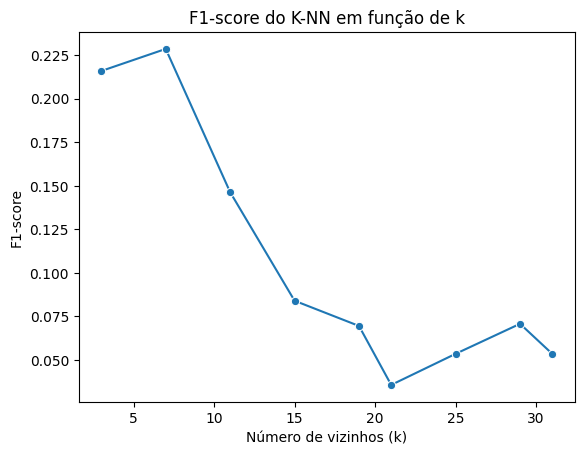

In [137]:
# gráfico para visualização da progressão do F1-score
ax = sns.lineplot(data=df_varia_vizinhos, x="número de vizinhos", y="F1-score", marker="o")
ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("F1-score")
ax.set_title("F1-score do K-NN em função de k")

Text(0.5, 1.0, 'F1-score do K-NN em função de k')

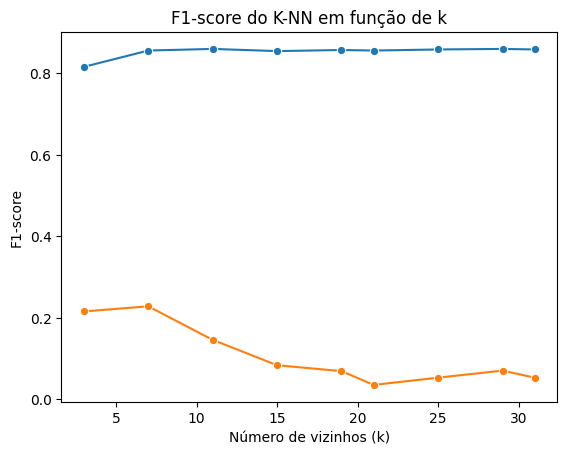

In [138]:
# gráfico para visualização da progressão da acurácia
ax = sns.lineplot(data=df_varia_vizinhos, x="número de vizinhos", y="acuracia", marker="o")
ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("Acurácia")
ax.set_title("Acurácia do K-NN em função de k")

# gráfico para visualização da progressão do F1-score
ax = sns.lineplot(data=df_varia_vizinhos, x="número de vizinhos", y="F1-score", marker="o")
ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("F1-score")
ax.set_title("F1-score do K-NN em função de k")

Avaliando os resultados da acurácia, é possível inferir que, para menores valores de K, a acurácia do modelo é menor, aumentando de modo praticamente exponencial com o aumento da quantidade de vizinhos. No entanto, para o F1-score, o melhor resultado se deu para 3 vizinhos. Esses comportamentos se explicam pois, avaliando poucos vizinhos, o modelo pode notar padrões onde não existem, adotando um comportamento de overfitting dada a alta variância entre as avaliações dos pontos.

Enquanto isso, para quantidades de vizinhos maiores, o modelo deixa de visualizar esses padrões fictícios, reduzindo a variância de suas atribuições. No entanto, se considerarmos valores muito altos de K, pode ocorrer o underfitting, com o modelo passando a considerar a moda existente entre os indivíduos avaliados, assim como faz um modelo baseline.

Com isso, devemos nos atentar à escolha de um K ideal, que nem faça um overfitting nem underfitting sobre os dados apresentados. Observando o gráfico conjunto para as curvas de progressão da acurácia e F1-score, temos que esse valor de K se encontra, aproximadamente, entre 11 e 19, apresentando altos F1-scores e também acurácia adequada, para os quais se espera resultados de previsões compatíveis.

Sob essa perspectiva, se adotarmos o F1-score como métrica de desempenho principal, a conclusão lógica seria escolher o número de vizinhos igual a 3. No entanto, comparando essa métrica aplicada aos dados de treino e teste do modelo, temos como diferença:

In [139]:
# instanciando e treinando o modelo com três vizinhos
modelo_k3 = KNeighborsClassifier(n_neighbors=3)
modelo_k3.fit(X_treino, y_treino)

# calculando o F1-score para cada caso
f1_treino = f1_score(y_treino, modelo_k3.predict(X_treino))
f1_teste = f1_score(y_teste, modelo_k3.predict(X_teste))

# detrminando a diferença entre os F1-scores
print(f"F1 no treino - F1 no teste = {f1_treino - f1_teste:.3f}")

F1 no treino - F1 no teste = 0.338


Ou seja, a diferença entre os F1-scores aplicados aos dados de treino e teste é de, aproximadamente, 0.34, evidenciando que o modelo se adapta muito melhor aos dados que já viu do que aqueles que deveria prever. Com isso, observamos diretamente que, com poucos vizinhos, o modelo passa a visualizar padrões onde eles não existem. Para evitar o overfitting nas análises desenvolvidas a seguir, optou-se por manter um número de vizinhos sempre maior ou igual a 13.

#### Variando a função de distância e avaliando as métricas

Nessa seção, serão avaliadas como diferentes funções de distância consideradas para determinar a distância entre os K vizinhos alteram as métricas de desempenho do modelo. Para isso, serão consideradas as seguintes funções de distância:

- "euclidean": distância euclidiana, é o padrão utilizado pelo modelo KNN. Nela, a distância entre os vizinhos é avaliada como a raiz quadrada da soma dos quadrados das diferenças das coordenadas de cada um deles, ou seja, é a distância "em linha reta" existente entre eles. [9] Sua representação adota a forma:

![](https://thumb.wikimedia.org/wikipedia/commons/thumb/5/55/Euclidean_distance_2d.svg/500px-Euclidean_distance_2d.svg.png?utm_source=pt.wikipedia.org&utm_campaign=parser&utm_content=thumbnail)

-"manhattan": distância de Manhattan, considera as diferenças absolutas entre as coordenadas das posições dos pontos, ou seja, avalia a distância a aprtir de trajetórias verticais ou horizontas, nunca diagonais. Costuma ser mais adequada do que a distância euclidiana para espaços de alta dimensão, como é o caso do que estamos avaliando, que conta com 21 atributos. [10] Sua representação é:

![](https://media.datacamp.com/cms/google/ad_4nxf7tzbgnr4agwisfup5dsnjdlgr8ljkdagxx3eignuhrtz9wkgnw5zotv4nzcesskhp2kahluoy5v64ka27raez21gk365_3jkpc7qgxjp_d-u9j4sdiiaf_7z1barfpafugokizbrifquazqgep5fgyz0g.png)

-"hamming": distância de hamming. Considera a distância de posições existentes entre dois vetores ou sequências; [11]

-"chebyschev": distância de Chebyschev. Considera a apenas a maior diferença entre as coordenadas de dois pontos, desconsiderando as demais. [12]

In [140]:
# lista que armazena as funções de distância testadas
FUNCOES_DISTANCIA = ["euclidean", "manhattan", "hamming", "chebyshev"] 

# laço de repetição para testar o KNN com diferentes funções de distância
for distancia in FUNCOES_DISTANCIA:
    # instanciando o modelo
    modelo_knn = KNeighborsClassifier(n_neighbors=21, metric=distancia)

    # treinando o modelo
    modelo_knn.fit(X_treino, y_treino)

    # obtendo a acurácia
    y_verdadeiro = y_teste
    y_previsao = modelo_knn.predict(X_teste)
    acuracia = accuracy_score(y_verdadeiro, y_previsao)
    f1 = f1_score(y_verdadeiro, y_previsao)

    print(f"A acurácia do modelo KNN usando metric = {distancia} foi de {acuracia*100:.2f}%, enquanto o F1_score igual a {f1*100:.2f}%.")

A acurácia do modelo KNN usando metric = euclidean foi de 85.60%, enquanto o F1_score igual a 3.57%.
A acurácia do modelo KNN usando metric = manhattan foi de 86.27%, enquanto o F1_score igual a 13.45%.
A acurácia do modelo KNN usando metric = hamming foi de 86.00%, enquanto o F1_score igual a 11.76%.
A acurácia do modelo KNN usando metric = chebyshev foi de 86.00%, enquanto o F1_score igual a 5.41%.


Avaliando os resultados tanto para a acurácia quanto F1-score de cada uma das funções de distância, podemos observar que a distância de Manhattan é a mais adequada para ambos, uma vez que é a mais sensível à distância absoluta entre dois pontos. 

Por fim, tamém podemos notar que a distância euclidiana, o padrão utilizado pelo modelo KNN, é aquela que apresenta as piores métricas de desempenho dentre as comparadas.

#### Variando os conjuntos de hiperparâmetros

Nesta seção, são avaliados como diferentes conjuntos de hiperparâmetros influenciam o desempenho do modelo KNN, sendo os resultados utilizados para definir quais métricas serão consideradas para a construção do modelo final. Para isso, serão consideradas seis diferentes números de vizinhos (K), todos ímpares, 4 tipos de funções de distância (as mesmas utilizadas e explicadas na seção anterior) e dois tipos de pesos, ou seja, de consideração para a influência de cada vizinho. Para a última categoria, serão considerados "uniform", em que cada vizinho, seja próximo ou distante, influencia igualmente na percepção do modelo; e "distance", em que vizinhos mais próximos tem peso maior na decisão do modelo do que vizinhos mais distantes.

No total, serão avaliados 48 conjuntos de hiperparâmetros para definir as melhores condições de aplicação do KNN.

In [141]:
# listas contendo as variações do número de vizinhos, pesos e métricas de distância
NUMERO_VIZINHOS = [13, 15, 19, 21, 25, 31]
PESOS = ["uniform", "distance"]
FUNCOES_DISTANCIA =  ["manhattan", "euclidean", "hamming", "chebyshev"]

# lista para armezar as métricas variadas e sua acurácia
resultados_hiperparametros = []

# laço de repetição para as métricas de distância
for distancia in FUNCOES_DISTANCIA:

    # instanciando o modelo
    modelo_knn = KNeighborsClassifier(metric=distancia, n_jobs=4)

    # treinando o modelo
    modelo_knn.fit(X_treino, y_treino)

    # laço de repetição para o número de vizinhos e o peso associado a eles
    for n_vizinho, peso in product(NUMERO_VIZINHOS, PESOS):

        # atualizando os parâmetros do modelo
        modelo_knn.set_params(n_neighbors=n_vizinho, weights=peso)
        
        # obtendo a acurácia
        y_verdadeiro = y_teste
        y_previsao = modelo_knn.predict(X_teste)
        acuracia = accuracy_score(y_verdadeiro, y_previsao)
        f1 = f1_score(y_verdadeiro, y_previsao)

        # adicionando o conjunto de hiperparâmetros e a acurácia obtida
        resultados_hiperparametros.append({
            "n_neighbors": n_vizinho,
            "weights": peso,
            "metric": distancia,
            "acuracia": acuracia,
            "f1_score": f1
        })

In [142]:
# verificando o DataFrame com os conjuntos de hiperparâmetros e suas acurácias
df_hiperparametros = pd.DataFrame(resultados_hiperparametros)
df_hiperparametros =  df_hiperparametros.sort_values(by='f1_score', ascending=False)
df_hiperparametros

,n_neighbors,weights,metric,acuracia,f1_score
12,13,uniform,euclidean,0.861333,0.174603
1,13,distance,manhattan,0.858667,0.171875
0,13,uniform,manhattan,0.861333,0.161290
13,13,distance,euclidean,0.858667,0.158730
24,13,uniform,hamming,0.862667,0.148760
25,13,distance,hamming,0.862667,0.148760
3,15,distance,manhattan,0.858667,0.145161
6,21,uniform,manhattan,0.862667,0.134454
9,25,distance,manhattan,0.861333,0.133333
27,15,distance,hamming,0.860000,0.132231


Avaliando os resultados dos diferentes parâmetros aplicados ao modelo KNN, ordenados a partir dos maiores resultados de F1-score, temos que as melhores métricas foram obtidas com 13 vizinhos, peso conforme a posição e distância euclidiana. Com isso, o número de vizinhos concorda com o que foi obtido ao variar apenas K, mas distância não, uma vez que a distância Euclidiana foi aquela que obteve o pior resultado individual dentre as comparadas.

Esse resultado mostra que, individualmente, apesar de uma métrica poder ser melhor do que outras, em conjunto elas se influenciam mutuamente, possibilitando obter os melhores parâmetros para o modelo.

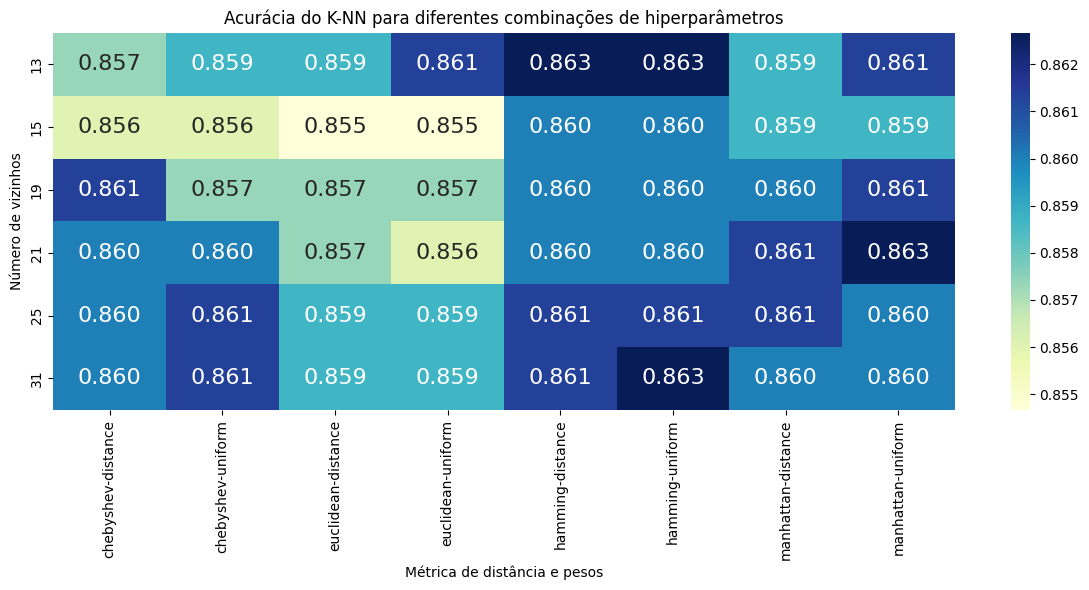

In [143]:
# heatmap para a acurácia registrada para os diferentes conjuntos de hiperparâmetros
tabela_acuracia = df_hiperparametros.pivot_table(
    index="n_neighbors",
    columns=["metric", "weights"],
    values="acuracia"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    tabela_acuracia,
    annot=True,
    annot_kws={"size": 16},
    fmt=".3f",
    cmap="YlGnBu"
)

plt.xlabel("Métrica de distância e pesos")
plt.ylabel("Número de vizinhos")
plt.title("Acurácia do K-NN para diferentes combinações de hiperparâmetros")
plt.tight_layout()

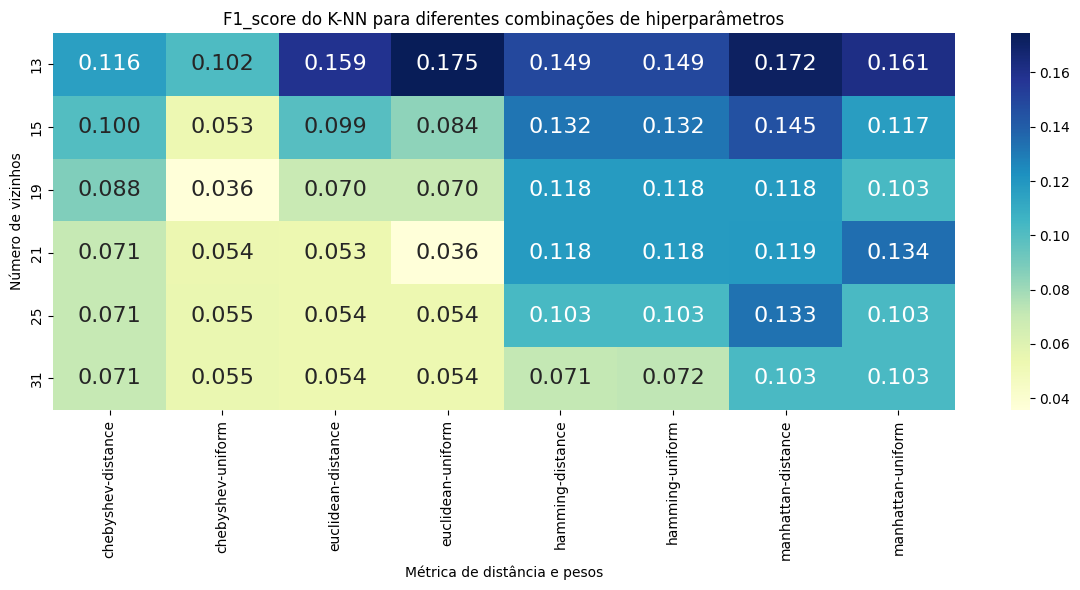

In [144]:
# heatmap para o F1-score registrado para diferentes conjuntos de hiperparâmetros
tabela_f1 = df_hiperparametros.pivot_table(
    index="n_neighbors",
    columns=["metric", "weights"],
    values="f1_score"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    tabela_f1,
    annot=True,
    annot_kws={"size": 16},
    fmt=".3f",
    cmap="YlGnBu"
)

plt.xlabel("Métrica de distância e pesos")
plt.ylabel("Número de vizinhos")
plt.title("F1_score do K-NN para diferentes combinações de hiperparâmetros")
plt.tight_layout()

Visualizando os heatmaps para o desempenho de cada conjunto de hiperparâmetros quanto à acurácia e F1-score, temos que, para ambos, os melhores resultados comuns ocorrem com o menor número de vizinhos (13). Isoladamente, para a acurácia, o melhor resultado foi para distância de hamming e peso uniforme com k=21, para o qual a acurácia foi de 85.5%. Enquanto isso, o F1-score ocorreu com a distância euclidiana, peso conforme a posição e 13 vizinhos, como já observado e explicado anteriormente.

#### Versão do KNN final com a melhor acurácia



Essa seção se dedica a estabelecer o modelo de KNN com melhor desempenho a partir dos conjuntos de hiperparâmetros, de modo a definir as condições que serão utilziadas para realizar as comparações nas seções seguintes do notebook.

In [145]:
# encontrando o modelo de KNN com a melhor acurácia a partir do DataFrame que armazenava os conjuntos de hiperparâmetros
melhor_acuracia = df_hiperparametros.loc[df_hiperparametros['acuracia'].idxmax()]
print("Conjunto de hiperparâmetros com melhor acurácia")
print(melhor_acuracia)

Conjunto de hiperparâmetros com melhor acurácia
n_neighbors          13
weights         uniform
metric          hamming
acuracia       0.862667
f1_score        0.14876
Name: 24, dtype: object


Considerando apenas a acurácia, temos que o melhor resultado foi obtido com 13 vizinhos, distância de hamming e pesos uniformes para os vizinhos. No entanto, seu F1-score é menor se comparado à outros conjuntos de hiperparâmetros.

In [146]:
# encontrando o modelo de KNN com a melhor acurácia a partir do DataFrame que armazenava os conjuntos de hiperparâmetros
melhor_f1 = df_hiperparametros.loc[df_hiperparametros['f1_score'].idxmax()]
print("Conjunto de hiperparâmetros com melhor F1_score")
print(melhor_f1)

Conjunto de hiperparâmetros com melhor F1_score
n_neighbors           13
weights          uniform
metric         euclidean
acuracia        0.861333
f1_score        0.174603
Name: 12, dtype: object


Avaliando o conjunto de hiperparâmetros com melhor F1-score, temos que esse se deu para k = 13, distância euclidiana e distância uniforme, sendo esse de 17.4%.

Nesse sentido, dado o desbalanceamento do conjunto de dados já explicado anteriormente, o conjunto de dados com melhor F1-score será estabelecido como o de melhor resultado, uma vez que espera-se obter um modelo que preveja adequadamente tanto não-diabéticos quanto, principalmente, diabéticos ou pré-diabéticos.

In [147]:
# definindo as condições de melhor F1-score para treinar o modelo
melhor_num_vizinhos = melhor_f1['n_neighbors']
melhor_peso = melhor_f1['weights']
melhor_distancia = melhor_f1['metric']

# instanciando treinando o modelo de KNN com base na melhor acurácia
modelo_knn_final = KNeighborsClassifier(
    n_neighbors= melhor_num_vizinhos,
    weights= melhor_peso,
    metric= melhor_distancia
)
modelo_knn_final.fit(X_treino, y_treino)

,n_neighbors,np.int64(13)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


[Text(0, 0.5, 'Não-diabético'), Text(0, 1.5, 'Diabético')]

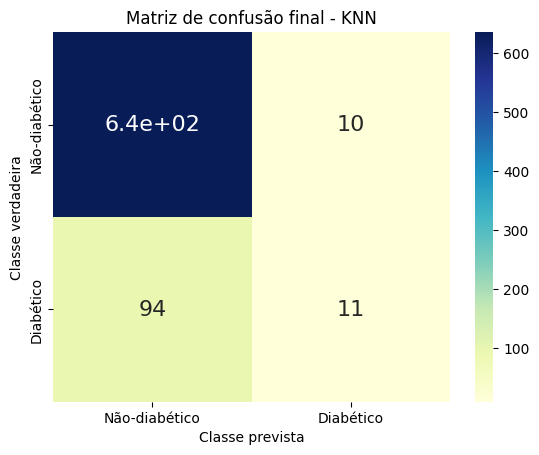

In [148]:
# criando a matriz de confusão para o KNN com melhor acurácia
y_verdadeiro = y_teste
y_previsao = modelo_knn_final.predict(X_teste)

matriz_conf_final = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_final = pd.DataFrame(matriz_conf_final, ordem_labels, ordem_labels)

matriz_conf_final = sns.heatmap(df_conf_final, annot=True, annot_kws={"size": 16}, cmap="YlGnBu");

matriz_conf_final.set_xlabel("Classe prevista")
matriz_conf_final.set_ylabel("Classe verdadeira")
matriz_conf_final.set_title("Matriz de confusão final - KNN")

matriz_conf_final.set_xticklabels(["Não-diabético", "Diabético"])
matriz_conf_final.set_yticklabels(["Não-diabético", "Diabético"])

Observando a matriz de confusão para o KNN final obtido a partir do conjunto de hiperparâmetros com melhor F1-score, temos que houve o aumento da quantidade de Verdadeiros Positivos (diabéticos identificados como tal), mostrando uma melhoria do modelo em cumprir o objetivo de identificar diabéticos. Houve também a redução da quantidade de falsos negativos, mas o aumento dos falsos postivos.

Assim, temos que houve uma melhoria das previsões do modelo, mas este ainda comete erros, principalmente em se tratando de prever Diabéticos quando o indivíduo não o é, ou seja, um Falso Positivo.

In [149]:
# calculando o F1-score para cada os dados de treino e teste do melhor KNN
f1_treino_final = f1_score(y_treino, modelo_knn_final.predict(X_treino))
f1_teste_final = f1_score(y_teste, modelo_knn_final.predict(X_teste))

# detrminando a diferença entre os F1-scores
print(f"F1 no treino - F1 no teste = {f1_treino_final - f1_teste_final:.3f}")
print(f"F1-score aplicado aos dados de treino: {f1_treino_final:.3f}")
print(f"F1-score aplicado aos dados de teste: {f1_teste_final}")

F1 no treino - F1 no teste = 0.060
F1-score aplicado aos dados de treino: 0.235
F1-score aplicado aos dados de teste: 0.1746031746031746


Note que, se considerarmos a mesma análise realizada anteriormente para avaliar se as previsões do modelo estão sofrendo com overfitting, ou seja, enxergando padrões onde eles não existem, iremos chegar a uma conclusão positiva. No entanto, essa não é verdadeira, uma vez que, considerando o peso "distance" durante a avaliação, um ponto com distância zero a si mesmo passa a ter peso praticamente infinito na consideração, o que torna o F1-score aplicado aos dados de treino praticamente igual a 1, fornecendo a falsa ideia de que o modelo está sofrendo com overfitting.

Assim, continuaremos utilizando as condições definidas anteriormente que resultaram no melhor F1-score para as avaliações subsequentes, confiando que o modelo não está realizando overfitting pois o número de vizinhos k, principal fonte da observação de padrões onde eles não existem, foi aumentado apra evitar esse problema.

#### Avaliando a importância final de cada atributo

Agora, sabendo quais condições tornam melhores as métricas de desempenho do modelo KNN, podemos investigar efetivamente quais atributos mais contribuem durante essa decisão. Desse modo, obtemos:

C:\Users\ana2610001\AppData\Local\Temp\ipykernel_25276\2291388698.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  eixo.set_xticklabels(eixo.get_xticklabels(), rotation=90);


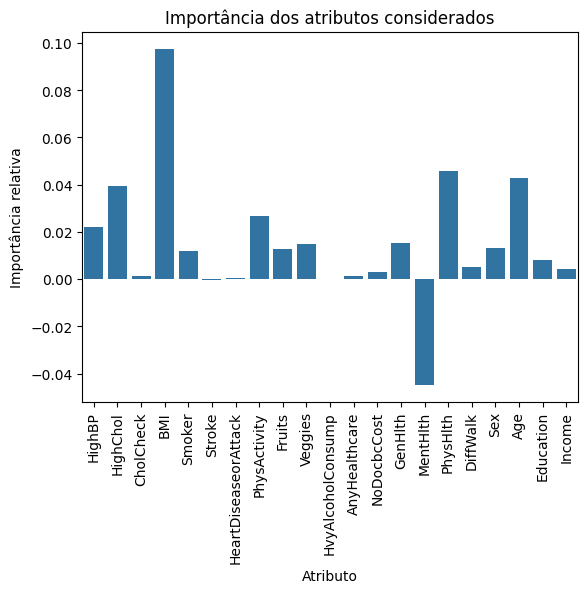

In [150]:
# definindo quantas vezes a ordem dos atributos será alterada
N_EMBARALHAMENTOS = 20

# calculando a importância de cada atributo por meio da permutação
resultado_importancia = permutation_importance(
    modelo_knn_final,
    X_teste,
    y_teste,
    n_repeats=N_EMBARALHAMENTOS,
    random_state=SEMENTE_ALEATORIA,
    scoring="f1",
)

# obtêm a importância média de cada atributo após os embaralhamentos
importancia = resultado_importancia.importances_mean

# plotando a importância de cada atributo em um gráfico de barras
eixo = sns.barplot(x=ATRIBUTOS, y=importancia)
eixo.set_ylabel("Importância relativa")
eixo.set_xlabel("Atributo")
eixo.set_title("Importância dos atributos considerados")
eixo.set_xticklabels(eixo.get_xticklabels(), rotation=90);

Observando o gráfico produzido, temos que houve uma grande inversão da importância relativa de cada um dos atributos avaliados, com a maioria deles que apresentava importância negativa com essa passando a ser positiva. No entanto, ainda se obsrva que o 'BMI' (índice de massa corporal), permanece sendo o atributo mais importante para a previsão final do modelo, enquanto 'MentHlth' segue sendo o de menor importância.

Nesse caso, o único atributo com contruibuição igual a zero é 'HvyAlcoholConsump', ou seja, o alto consumo de bebidas alcoólicas, assim como ocorria no modelo inicial.

### Normalizando os dados e avaliando o algoritmo KNN

Nesta seção, será avaliado como diferentes normalizadores aplicados aos atributos do modelo podem alterar o resultado das métricas de desempenho. Isso pois, tendo atributos com uma escala muito maior do que os demais, como é o caso do BMI se comparado aos dados binários, esse será o principal considerado para avaliar as distâncias, tornando-se o atributo de maior importância, como já foi verificado anteriormente.

Assim, diferentes normalizadores serão avaliados para verificar se colocar os dados em uma mesma escala altera o desempenho do modelo. [13]

#### Normalização usando o normalizador padrão "Standard-scaler"

A primeira normalização avaliada será a normalização padrão utilizando o "StandatdScaler". Essa normalização tem por objetivo transformar a média dos dados em zero e o desvio padrão em 1, isso sem alterar o formato da distribuição em que os dados se encontram, de modo que é uma boa estratégia a ser implementada para o algoritmo KNN, que visualiza a distância entre vizinhos.

In [151]:
# instanciando o normalizador
normalizador = StandardScaler()

# ajustando o normalizador aos dados
normalizador.fit(X_treino)

# aplicando o normalizador aos atributos armazenados no DataFrame
X_treino_norm_standard = pd.DataFrame(normalizador.transform(X_treino), columns=ATRIBUTOS, index=X_treino.index)
X_teste_norm_standard = pd.DataFrame(normalizador.transform(X_teste), columns=ATRIBUTOS, index=X_teste.index)

Para os dados normalizados usando o normalizador padrão:
Acurácia = 86.80
F1 score =  23.26


[Text(0, 0.5, 'Não-diabético'), Text(0, 1.5, 'Diabético')]

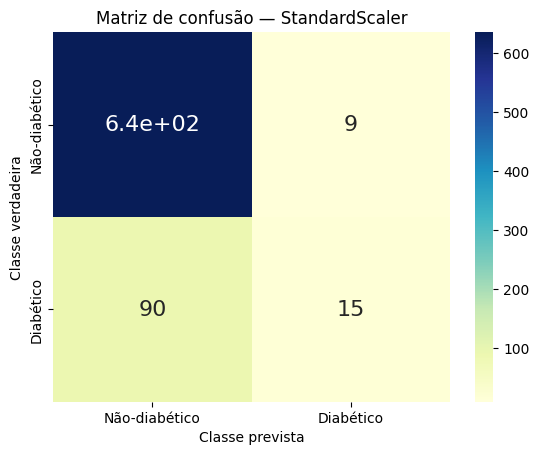

In [152]:
# instanciando o modelo
modelo_knn_norm_standard = KNeighborsClassifier(
    n_neighbors= melhor_num_vizinhos,
    weights= melhor_peso,
    metric= melhor_distancia
    )

# treinando o modelo
modelo_knn_norm_standard.fit(X_treino_norm_standard, y_treino)
y_previsao = modelo_knn_norm_standard.predict(X_teste_norm_standard)

# obtendo a acurácia e F1-score
acuracia_standard = accuracy_score(y_teste, y_previsao)
f1_standard = f1_score(y_teste, y_previsao)

print(f"Para os dados normalizados usando o normalizador padrão:")
print(f"Acurácia = {acuracia_standard*100:.2f}")
print(f"F1 score =  {f1_standard*100:.2f}")

# gerando a matriz de confusão do modelo com dados normalizados
y_previsao_standard = modelo_knn_norm_standard.predict(X_teste_norm_standard)

matriz_conf_standard = confusion_matrix(y_teste, y_previsao_standard, labels=ordem_labels)
df_conf_standard = pd.DataFrame(matriz_conf_standard, ordem_labels, ordem_labels)

eixo = sns.heatmap(df_conf_standard, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe verdadeira")
eixo.set_title("Matriz de confusão — StandardScaler")
eixo.set_xticklabels(["Não-diabético", "Diabético"])
eixo.set_yticklabels(["Não-diabético", "Diabético"])

Avaliando as métricas de desempenho dos dados normalizados com StandardScaler, temos que todas elas foram melhoradas se comparadas aos resultados do melhor conjunto de hiperparâmetros. Com a matriz de confusão, podemos observar que a previsão correta de diabéticos foi melhorada, enquanto tanto Falsos Positivos quanto Falsos Negativos tiveram suas previsões reduzidas, evidenciando a melhoria das previsões se comparadas aos dados não-normalizados.

#### Normalização pelo máximo absoluto usando "MaxAbsScaler"

A normalização pelo máximo absoluto utilizando o normalizador "MaxAbsScaler" busca assegurar que todos os dados estejam localizados no intervalo [-1, 1]. Desse modo, ela mantém a esparsidade dos dados.

In [153]:
# instanciando o normalizador
normalizador = MaxAbsScaler()

# ajustando o normalizador aos dados
normalizador.fit(X_treino)

# aplicando o normalizador aos atributos armazenados no DataFrame
X_treino_norm_MaxAbs = pd.DataFrame(normalizador.transform(X_treino), columns=ATRIBUTOS, index=X_treino.index)
X_teste_norm_MaxAbs = pd.DataFrame(normalizador.transform(X_teste), columns=ATRIBUTOS, index=X_teste.index)

Para os dados normalizados usando o normalizador pelo máximo absoluto:
Acurácia = 85.87
F1 score =  14.52


[Text(0, 0.5, 'Não-diabético'), Text(0, 1.5, 'Diabético')]

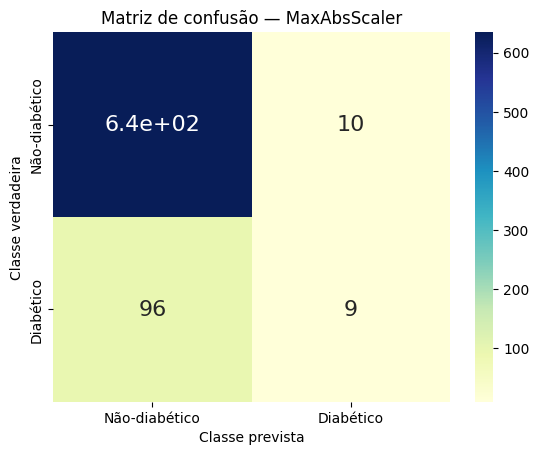

In [154]:
# instanciando o modelo
modelo_knn_norm_Max_Abs = KNeighborsClassifier(
    n_neighbors= melhor_num_vizinhos,
    weights= melhor_peso,
    metric= melhor_distancia
    )

# treinando o modelo
modelo_knn_norm_Max_Abs.fit(X_treino_norm_MaxAbs, y_treino)
y_previsao = modelo_knn_norm_Max_Abs.predict(X_teste_norm_MaxAbs)

# obtendo a acurácia e F1-score
acuracia_Max_Abs = accuracy_score(y_teste, y_previsao)
f1_Max_Abs = f1_score(y_teste, y_previsao)

print(f"Para os dados normalizados usando o normalizador pelo máximo absoluto:")
print(f"Acurácia = {acuracia_Max_Abs*100:.2f}")
print(f"F1 score =  {f1_Max_Abs*100:.2f}")

# gerando a matriz de confusão obtida para os atributos normalizados
y_previsao_MaxAbs = modelo_knn_norm_Max_Abs.predict(X_teste_norm_MaxAbs)

matriz_conf_MaxAbs = confusion_matrix(y_teste, y_previsao_MaxAbs, labels=ordem_labels)
df_conf_maxabs = pd.DataFrame(matriz_conf_MaxAbs, ordem_labels, ordem_labels)

eixo = sns.heatmap(df_conf_maxabs, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe verdadeira")
eixo.set_title("Matriz de confusão — MaxAbsScaler")
eixo.set_xticklabels(["Não-diabético", "Diabético"])
eixo.set_yticklabels(["Não-diabético", "Diabético"])

Avaliando os resultados das métricas de desempenho obtidas utilizando o normalizador pelo máximo absoluto, temos que todas elas pioram se comparadas aos dados sem normalização. Além disso, por meio da matriz de confusão, podemos notar que sua previsão de Verdadeiros Positivos é reduzida em uma unidade, enquanto Falsos Negativos são acrescidos em uma unidade, de modo que é possível visualizar que essa não é uma boa estratégia a ser aplicada ao modelo KNN.

#### Normalização pelo mínimo e máximo usando "MinMaxScaler"

O normalizador pelo mínimo e máximo utilizando o "MinMaxScaler" modifica os dados de modo que, após a transformação, eles estejam contidos no intervalo [0, 1], com o menor valor sendo igual a zero e o maior igual a 1. Sua vantagem é conhecer quais são os valores de máximo e mínimo, no entanto, essa normalização afeta a esparsidade dos dados, de modo que não costuma ser um boa estratégia a ser adotada.

In [155]:
# instanciando o normalizador
normalizador = MinMaxScaler()

# ajustando o normalizador
normalizador.fit(X_treino)

# aplicando o normalizador aos atributos armazenados no DataFrame
X_treino_norm_MinMax = pd.DataFrame(normalizador.transform(X_treino), columns=ATRIBUTOS, index=X_treino.index)
X_teste_norm_MinMax = pd.DataFrame(normalizador.transform(X_teste), columns=ATRIBUTOS, index=X_teste.index)

Para os dados normalizados usando o normalizador pelo mínimo e máximo:
Acurácia = 86.00
F1 score =  16.00


[Text(0, 0.5, 'Não-diabético'), Text(0, 1.5, 'Diabético')]

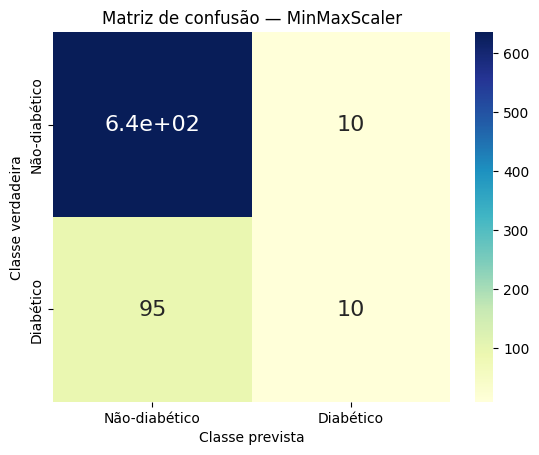

In [156]:
# instanciando o modelo
modelo_knn_norm_MinMax = KNeighborsClassifier(
    n_neighbors= melhor_num_vizinhos,
    weights= melhor_peso,
    metric= melhor_distancia
    )

# treinando o modelo
modelo_knn_norm_MinMax.fit(X_treino_norm_MinMax, y_treino)
y_previsao = modelo_knn_norm_MinMax.predict(X_teste_norm_MinMax)

# obtendo a acurácia e F1-score
acuracia_Min_Max = accuracy_score(y_teste, y_previsao)
f1_Min_Max = f1_score(y_teste, y_previsao)

print(f"Para os dados normalizados usando o normalizador pelo mínimo e máximo:")
print(f"Acurácia = {acuracia_Min_Max*100:.2f}")
print(f"F1 score =  {f1_Min_Max*100:.2f}")

# gerando a matriz de confusão com os dados normalizados
y_previsao_MinMax = modelo_knn_norm_MinMax.predict(X_teste_norm_MinMax)

matriz_conf_MinMax = confusion_matrix(y_teste, y_previsao_MinMax, labels=ordem_labels)
df_conf_MinMax = pd.DataFrame(matriz_conf_MinMax, ordem_labels, ordem_labels)

eixo = sns.heatmap(df_conf_MinMax, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe verdadeira")
eixo.set_title("Matriz de confusão — MinMaxScaler")
eixo.set_xticklabels(["Não-diabético", "Diabético"])
eixo.set_yticklabels(["Não-diabético", "Diabético"])

Avaliando os resultados das normalizações pelo mínimo e máximo, temos que as métricas de desempenho do modelo (acurácia e F1-score) são levemente reduzidas. No entanto, a matriz de confusão não sofre alterações. Assim, essa não é uma boa estetégia de aplicação aos dados, mas ainda é melhor do que a normalização pelo máximo absoluto.

#### Comparando as normalizações

In [157]:
# gerando o DataFrame de comparação entre as normalizações e os resultados não-normalizados
resultados_normalizacao = pd.DataFrame([
    {"normalizador": "Sem normalização", "acuracia": melhor_f1["acuracia"], "f1": melhor_f1["f1_score"]},
    {"normalizador": "StandardScaler", "acuracia": acuracia_standard, "f1": f1_standard},
    {"normalizador": "MaxAbsScaler", "acuracia": acuracia_Max_Abs, "f1": f1_Max_Abs},
    {"normalizador": "MinMaxScaler", "acuracia": acuracia_Min_Max, "f1": f1_Min_Max},
])

resultados_normalizacao.round(3)

,normalizador,acuracia,f1
0,Sem normalização,0.861,0.175
1,StandardScaler,0.868,0.233
2,MaxAbsScaler,0.859,0.145
3,MinMaxScaler,0.860,0.160


Comparando os resultados das métricas de desempenho obtidas para os dados sem normalização e com a aplicação das três normalizações anteriores, temos que o melhor resultado se deu co a normalização usando o normalizador padrão StandardScaler. Nela, observamos tanto um pequeno ganho na acurácia (de 0.7%) quanto no F1-score, que foi de 17.4% nos dados sem normalização para 23.3% nos dados normalizados.

### Teste de hipótese 1 - Codificar alguns dos atributos alteraria o resultado?

Os dados categóricos ordinais do dataset utilizado já são codificados, de modo que, durante o tratamento de dados, não foi necessário aplicar o codificador a eles. No entanto, se isso fosse necessário, poderíamos ter utilziado o codificar ordinal OrdinalEncoder, mantendo a hierarquia existente entre os dados.

Há ainda outra estratégia de codificação utilizando o OneHotEncoder, para a qual os rótulos dos dados passam a ser 0 ou 1. Desse modo, aplicando isso aos atributos dos dataset, poderíamos tornar todos eles binários. Assim, essa seção se dedica ao teste da hipótese: "Alterar a codificação dos dados, tornando todos eles binários, provocaria mudanças nas métricas de desempenho?".

Codificando as colunas com dados ordinais, obtemos:
Acurácia = 85.33
F1 score =  8.33


[Text(0, 0.5, 'Não-diabético'), Text(0, 1.5, 'Diabético')]

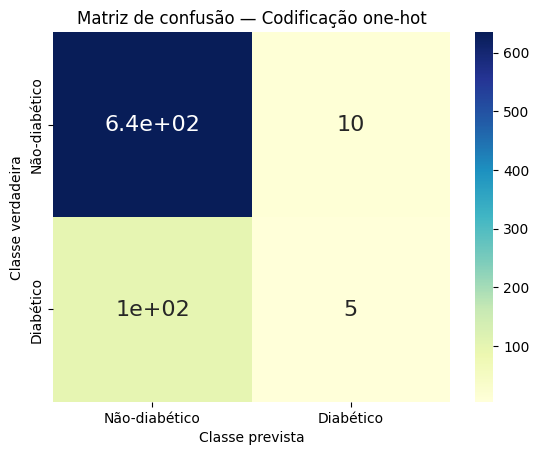

In [158]:
# obtendo as colunas com dados ordinais
COLUNAS_ORDINAIS = ['GenHlth', 'Age', 'Education', 'Income']

# instanciando o codificador
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# ajustando o codificador aos dados
encoder.fit(X_treino[COLUNAS_ORDINAIS])

# aplicando o codificador apenas às colunas do DataFrame selecionadas como ordinais
colunas_encoded_treino = encoder.transform(X_treino[COLUNAS_ORDINAIS])
colunas_encoded_teste = encoder.transform(X_teste[COLUNAS_ORDINAIS])


nomes_colunas_encoded = encoder.get_feature_names_out(COLUNAS_ORDINAIS)

df_encoded_treino = pd.DataFrame(colunas_encoded_treino, columns=nomes_colunas_encoded, index=X_treino.index)
df_encoded_teste = pd.DataFrame(colunas_encoded_teste, columns=nomes_colunas_encoded, index=X_teste.index)

# juntando todas as colunas, inclusive as codificadas, em um único DataFrame
X_treino_onehot = pd.concat([X_treino.drop(columns=COLUNAS_ORDINAIS), df_encoded_treino], axis=1)
X_teste_onehot = pd.concat([X_teste.drop(columns=COLUNAS_ORDINAIS), df_encoded_teste], axis=1)


# instanciando o modelo
modelo_knn_onehot = KNeighborsClassifier(
    n_neighbors= melhor_num_vizinhos,
    weights= melhor_peso,
    metric= melhor_distancia
    )

# treinando o modelo
modelo_knn_onehot.fit(X_treino_onehot, y_treino)
y_previsao = modelo_knn_onehot.predict(X_teste_onehot)

# obtendo a acurácia e F1-score
acuracia = accuracy_score(y_teste, y_previsao)
f1 = f1_score(y_teste, y_previsao)

print(f"Codificando as colunas com dados ordinais, obtemos:")
print(f"Acurácia = {acuracia*100:.2f}")
print(f"F1 score =  {f1*100:.2f}")

# gerando a matriz de confusão obtida com os atributos recodificados
y_previsao_onehot = modelo_knn_onehot.predict(X_teste_onehot)

matriz_conf_onehot = confusion_matrix(y_teste, y_previsao_onehot, labels=ordem_labels)
df_conf_onehot = pd.DataFrame(matriz_conf_onehot, ordem_labels, ordem_labels)

eixo = sns.heatmap(df_conf_onehot, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe verdadeira")
eixo.set_title("Matriz de confusão — Codificação one-hot")
eixo.set_xticklabels(["Não-diabético", "Diabético"])
eixo.set_yticklabels(["Não-diabético", "Diabético"])

Avaliando os resultados das métricas de desempenho após a codificação, temos que, comparado tanto ao melhor conjunto de padrâmetros sem normalização e com a aplicação do normalizador padrão, houve uma queda de cerca de 1% da acurácia, enquanto o F1-score foi reduzido pela metade, aproximadamente. Verificando a matriz de confusão, temos que as previsões de Verdadeiro Negativo e Falso Positivo se mantêm, enquanto há uma piora na previsão de diabéticos e aumento na quantidade de Falsos Negativos. Com isso, podemos concluir que codificar os dados de uma forma que não se adequa à sua natureza altera negativamente as previsões do modelo, sendo essa uma prática que não deve ser realizada.

### Teste de hipótese 2 - Qual seria o resultado de um modelo que normaliza e codifica os dados?

Anteriormente, verificamos que aplicar o normalizador padrão aos atributos do modelo melhora seu desempenho, enquanto codificá-los, descartando a noção de hierarquia existente, piora essas métricas. Assim, nessa seção, iremos avaliar como essas estratégias se comportam em conjunto e se isso melhora ou piora o desempenho do modelo.

Métricas de desempenho obtidas normalizando e codificando os atributos do modelo
Acurácia = 85.47
F1 score = 9.92


[Text(0, 0.5, 'Não-diabético'), Text(0, 1.5, 'Diabético')]

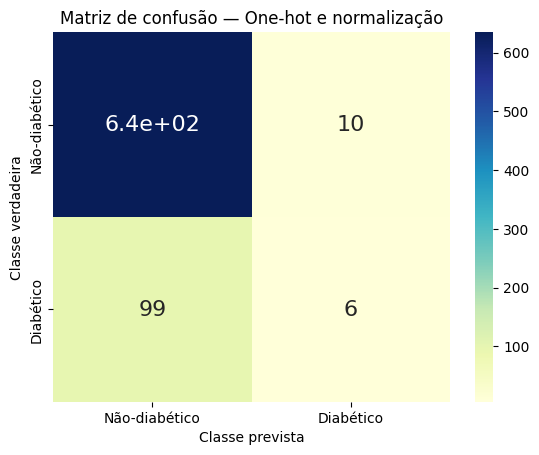

In [159]:
# instanciando e aplicando o normalizador com melhor resultaodo (normalizador padrão)
normalizador = StandardScaler()
normalizador.fit(X_treino_onehot)

# normalizaando os atributos de treino e teste
X_treino_onehot_norm = pd.DataFrame(normalizador.transform(X_treino_onehot), columns=X_treino_onehot.columns, index=X_treino_onehot.index)
X_teste_onehot_norm = pd.DataFrame(normalizador.transform(X_teste_onehot), columns=X_teste_onehot.columns, index=X_teste_onehot.index)

# instanciando o modelo
modelo_norm_onehot = KNeighborsClassifier(n_neighbors=melhor_num_vizinhos, weights=melhor_peso, metric=melhor_distancia)

# treinando o model
modelo_norm_onehot.fit(X_treino_onehot_norm, y_treino)
y_previsao = modelo_norm_onehot.predict(X_teste_onehot_norm)

# obtendo a acurácia e F1_score
print("Métricas de desempenho obtidas normalizando e codificando os atributos do modelo")
print(f"Acurácia = {accuracy_score(y_teste, y_previsao)*100:.2f}")
print(f"F1 score = {f1_score(y_teste, y_previsao)*100:.2f}")

# gerando a matriz de confusão com os dados normalizados e codificados
y_previsao_onehot_norm = modelo_norm_onehot.predict(X_teste_onehot_norm)

matriz_conf_onehot_norm = confusion_matrix(y_teste, y_previsao_onehot_norm, labels=ordem_labels)
df_conf_onehot_norm = pd.DataFrame(matriz_conf_onehot_norm, ordem_labels, ordem_labels)

eixo = sns.heatmap(df_conf_onehot_norm, annot=True, annot_kws={"size": 16}, cmap="YlGnBu")
eixo.set_xlabel("Classe prevista")
eixo.set_ylabel("Classe verdadeira")
eixo.set_title("Matriz de confusão — One-hot e normalização")
eixo.set_xticklabels(["Não-diabético", "Diabético"])
eixo.set_yticklabels(["Não-diabético", "Diabético"])

Observando os resultados das métricas de desempenho obtidas e comparando-as ao modelo em que não houve normalização, houve apenas a normalização padrão e houve apenas a codificação, podemos observar uma redução se comaprada aos dois primeiros, que se consolidaram até o momento como as melhores estatégias. No entanto, se comparada à hipótese testada na seção anterior, em que apenas se codificou os dados, aplicar também o normalizador a eles melhorou seus resultados.

Visualizando sua matriz de desempenho, temos que que suas previsões de Verdadeiro Negativo e Falso Positivo foram mantidas em comparação ao resultado do KNN com o melhor conjunto de hiperparâmetros sem normalização. Mas seu reconhecimento de diabéticos, ou seja, Verdadeiros Positivos sofreu uma redução, enquanto a de Falsos Negativos foi aumentada, evidenciando que essa ainda não é uma boa estratégia a ser aplicada aos dados, ainda que seja melhor do que apenas codificar os atributos sem normalizá-los

### Avaliação do modelo baseline

Nessa seção, será avaliado um modelo de Baseline para verificar seu desempenho e compará-lo ao KNN treinado anteriormente, tanto normalizado quanto sem normalização. O modelo Baseline é um modelo simples que prevê apenas a classe mais observada durante a etapa de treinos, ou seja, no caso do dataset empregado, ele irá prever que todos os indivíduos reservados para a etapa de testes não apresenntam diabetes, ainda que 14% deles o faça. Assim, o esperado é que esse modelo apresente um desempenho menor se comparado ao KNN, uma vez que não considera quaisquer características importantes no reconhecimento de diabéticos.

In [160]:
# instanciando o modelo Baseline
modelo_baseline = DummyClassifier(strategy='prior')

# treinando o modelo
modelo_baseline.fit(X_treino, y_treino)

,strategy,'prior'
,random_state,None
,constant,None


[Text(0, 0.5, 'Não-diabético'), Text(0, 1.5, 'Diabético')]

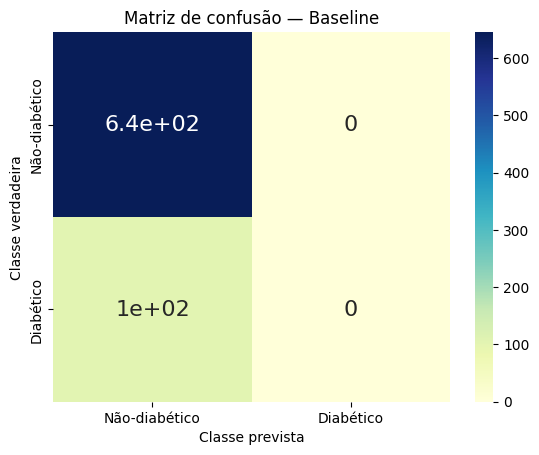

In [161]:
# gerando a matriz de confusão para o baseline
y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

matriz_conf_baseline = sns.heatmap(df_conf, annot=True, annot_kws={"size": 16}, cmap="YlGnBu");

matriz_conf_baseline.set_xlabel("Classe prevista")
matriz_conf_baseline.set_ylabel("Classe verdadeira")
matriz_conf_baseline.set_title("Matriz de confusão — Baseline")

matriz_conf_baseline.set_xticklabels(["Não-diabético", "Diabético"])
matriz_conf_baseline.set_yticklabels(["Não-diabético", "Diabético"])

In [162]:
# obtendo a acurácia
acuracia = accuracy_score(y_verdadeiro, y_previsao)
f1 = f1_score(y_verdadeiro, y_previsao)

print(f"Acurácia = {(acuracia*100):.2f}%")
print(f"F1_score = {f1*100:.2f}%")

Acurácia = 86.00%
F1_score = 0.00%


Observando os resultados das métricas de desempenho do modelo Baseline e sua matriz de confusão, temos que, conforme o esperado, ele prevê apenas a classe de não-diabéticos. Isso faz com que sua acurácia, ou seja, taxa de acerto, seja de 86%, dado o desbalanceamento presente no conjunto de dados. No entanto, observando o F1-score, temos que esse é igual a 0, mostrando que o modelo não é bom em prever tanto não-diabéticos quanto diabéticos, dado evidente a partir da matriz de confusão, em que mais de 100 Falsos Negativos são registrados.

Assim, ainda que a acurácia desse modelo se aproxime da registrada pelo KNN, observando seu F1-score e matriz de desempenho, temos que não se trata de um bom modelo para prever diabéticos, não cumprindo a função básica que um bom modelo deveria realizar.

### Quais os resultados de diferentes métricas de desempenho?

Nesta seção, serão avaliadas como diferentes métricas de desempenho são capazes de avaliar os resultados dos modelos KNN com o melhor conjunto de hiperparâmetros; KNN com o melhor conjunto de hiperparâmetros e com os atributos normalizados; e Baseline. Para isso, as métricas consideradas serão:


- Acurácia: mede a relação entre as previsões corretas realizadas pelo modelo e o total de previsões, ou seja, é da forma: $$\dfrac{VP + VN}{VP + VN + FP + FN}, $$ onde VP são os verdadeiros positivos, VN os verdadeiros negativos, FP os falsos positivos e FN os falsos negativos. Assim, ela não considera o papel das previsões falsas realizadas pelo modelo, o que é de extrema importância em se tratando do contexto de saúde avaliado; [2]


- Precisão: indica a taxa de previsão do modelo para a classe positiva, ou seja, diabéticos e pré-diabéticos, a partir da relação entre as previsões corretas para essa classe o total de previsões feitas para ela. Assim, ela adota a forma $$\dfrac{VP}{VP + FP}, $$ de modo que uma precisão baixa indica que o modelo está prevendo muitos falsos positivos; [14]


- Recall (Sensibilidade): indica qual fração da classe positiva o modelo previu corretamente, verificando quantos diabéticos o modelo deixou de reconhecer, nesse caso. Com isso, sua representação é da forma $$\dfrac{VP}{VP + FN},$$ onde um recall baixo indica uma ampla previsão de falsos negativos, o que é preocupante em um cenário de saúde, uma vez que, sem o diagnóstico, as pessoas não buscariam o tratamento adequado; [14]


- F1-score: indica a média harmônica entre a precisão e o recall, ou seja, é igual a $2 \cdot \dfrac{Precisão \cdot Recall}{Precisão + Recall}$. Desse modo, ele apenas é alto quando tanto a precisão quanto o recall são altos, indicando que o modelo equilibra bem falsos positivos e falsos negativos. Isso explica o motivo de essa ser a principal métrica de desempenho adotada durante o notebook, uma vez que as previsões falsas do modelo são justamente o que buscamos evitar/minimizar; [14]


- AUC-ROC: avalia o modelo considerando todos os limiares de decisão possíveis, ou seja, mede a capacidade que o modelo tem de diferenciar duas classes. [15]

In [163]:
def calcular_diferentes_metricas(y_real, previsao, probabilidade):
    """Função que calcula as diferentes métricas de desempenho para um modelo
    
    Args:
        y_real: resultado verdadeiro esperado
        previsao: resultado previsto pelo modelo
        probabilidade: probabilidade prevista para a classe positiva (ter diabetes)

    Returns: dicionário contendo as métricas de desempenho de Acurácia, Precisão, Recall, F1_score e AUC_ROC
    """

    return {
        "Acurácia": accuracy_score(y_real, previsao),
        "Precisão": precision_score(y_real, previsao),
        "Recall": recall_score(y_real, previsao),
        "F1_score": f1_score(y_real, previsao),
        "AUC_ROC": roc_auc_score(y_real, probabilidade),
    }

# calculando as métricas de desempenho para os modelos KNN, KNN com normalizador padrão e Baseline
diferentes_metricas_knn = calcular_diferentes_metricas(y_teste, modelo_knn_final.predict(X_teste), modelo_knn_final.predict_proba(X_teste)[:, 1])
diferentes_metricas_knn_standard = calcular_diferentes_metricas(y_teste, modelo_knn_norm_standard.predict(X_teste_norm_standard), modelo_knn_norm_standard.predict_proba(X_teste_norm_standard)[:, 1])
diferentes_metricas_baseline = calcular_diferentes_metricas(y_teste, modelo_baseline.predict(X_teste), modelo_baseline.predict_proba(X_teste)[:, 1])

# imprimindo as métricas de desempenho dos modelos em um DataFrame
df_metricas = pd.DataFrame([diferentes_metricas_knn,diferentes_metricas_knn_standard, diferentes_metricas_baseline], index=["KNN", "KNN normalizado", "Baseline"]).T

df_metricas.round(3)

c:\venv\ilumpy\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,KNN,KNN normalizado,Baseline
Acurácia,0.861,0.868,0.86
Precisão,0.524,0.625,0.00
Recall,0.105,0.143,0.00
F1_score,0.175,0.233,0.00
AUC_ROC,0.763,0.754,0.50


Avaliando os resultados das métricas de desempenho para os diferentes modelos, é possível notar que, na comparação entre o KNN sem normalização e aquele em que se aplicou o normalizador padrão, o segundo apresenta melhores resultados para todas as métricas, com excessão da AUC-ROC. Ou seja, comprova-se que o KNN normalizado fornece uma melhor previsão do que o KNN sem normalização, equilibrando bem as previsões de Falsos Positivos e Negativos, conforme seria esperado em um contexto de saúde. Quanto ao AUC-ROC, temos que o KNN sem normalização é um pouco melhor do que o KNN com os atributos normalizados, mostrando que esse prevê bem a hierarquia entre quais indivíduos são mais prováveis ou não de apresetarem diabetes.

Já para o Baseline, sua única métrica competitiva com o KNN é a acurácia, o que, em uma análise apenas dela, poderia fornecer a falsa impressão de que o Baseline é um modelo adequado para a aplicação a esse Dataset, quando, na realidade, não o é. Observando suas métricas de precisão, recall e F1-score, nota-se que todas elas são iguais a zero, demonstrando que o modelo é incapaz de reconhecer Verdadeiros Positivos, o que deveria ser justamente seu objetivo. Seu AUC-ROC foi igual a 0.5, mostrando que o modelo reconhece igualmente diabéticos/pré-diabéticos e não-diabéticos, sem capacidade de diferenciá-los.

#### Gerando a curva de comparação de AUC-ROC entre o KNN de melhor resultado e o Baseline

A curva ROC produzida a seguir busca apresentar a capacidade de discriminação entre diabético e não-diabéticos de cada um dos modelos avaliados. Assim, serão avaliados cada um dos limiares de decisão, e não apenas o padrão 0.5 de todos os modelos, de modo a tornar possível identificar qual limiares garantem ao modelo uma menor taxas de falso positivo e maior de verdadeiro positivo.

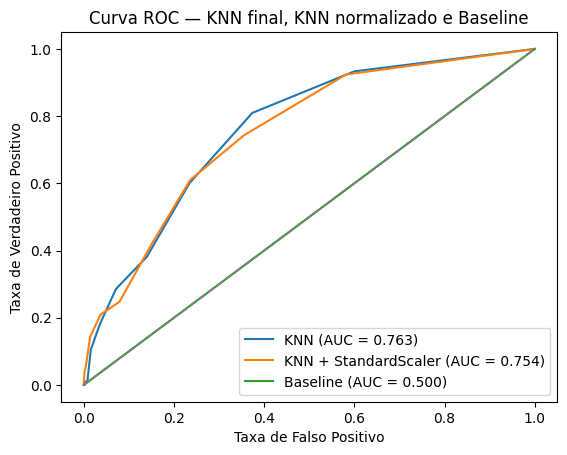

In [164]:
# determinando as taxas de falso positivo e verdadeiro positivo para cada modelo
fpr_knn, tpr_knn, _ = roc_curve(y_teste, modelo_knn_final.predict_proba(X_teste)[:, 1])
fpr_knn_norm, tpr_knn_norm, _ = roc_curve(y_teste, modelo_knn_norm_standard.predict_proba(X_teste_norm_standard)[:, 1])
fpr_base, tpr_base, _ = roc_curve(y_teste, modelo_baseline.predict_proba(X_teste)[:, 1])

# plotando o gráfico de comparação entre os modelos
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {diferentes_metricas_knn["AUC_ROC"]:.3f})')
plt.plot(fpr_knn_norm, tpr_knn_norm, label=f'KNN + StandardScaler (AUC = {diferentes_metricas_knn_standard["AUC_ROC"]:.3f})')
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {diferentes_metricas_baseline["AUC_ROC"]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.title("Curva ROC — KNN final, KNN normalizado e Baseline")
plt.legend();

Avaliando as curvas produzidas, podemos observar que o modelo Baseline se mantêm fiel à diagonal do gráfico, isso pois o modelo atribui a mesma probabilidade a todas as observações, sem hierarquizá-las. Enquanto isso, para os modelos KNNs, observamos curvas que se afastam da diagonal em sentido ao canto superior esquerdo do gráfico, mostrando a tendência que o modelo tem de buscar aumentar a taxa de verdadeiro positivo e reduzir a de falso positivo, aprendendo com os dados com que foi treinado. Com isso, essa é uma prova concreta da eficácia do KNN se comparado ao modelo de Baseline.

----

## Conclusões e principais aprendizados

Portanto, o notebook desenvolvido para a atividade permitiu a verificação de como o algoritmo KNN é influenciado por diferentes condições, como a quantidade k de vizinhos, o peso atribuído aos vizinhos conforme sua proximidade com a observação avaliada e a função de distância escolhida. Além disso, foi possível notar como diferentes estratégias de codificação e normalização afetam os resultados observados.

Nesse sentido, se tratando de um Dataset desbalanceado e com grande volume de dados, foi necessária a implementação de uma estratégia de amostragem para selecionar apenas uma fração dos dados presentes nele para que pudessem ser utilizados durante o notebook em um tempo hábil de execução. O desbalanceamento consistiu na principal dificuldade observada durante o desenvolvimento do notebook, uma vez que apenas o uso da acurácia para classificar o melhor modelo poderia indicar que o Baseline seria melhor do que o KNN em alguns casos, o que não se mostrou verdadeiro. Desse modo, foi necessário inserir o F1-score como métrica adicional, demonstando a ineficácia do modelo de Baseline em equilibrar e minimizar previsões falsas ao prever apenas indivíduos não-diabéticos.

Observando apenas a variação do número k de vizinhos, foi possível notar que a acurácia aumentava com o aumento do número de vizinhos, enquanto o maior F1-score foi registrado para o menor número de vizinhos avaliado (3). Com isso, o esperado seria que, com k=3, o modelo apresentasse um bom desempenho. No entanto, ao observar sua aplicação aos dados de treino e teste, concluiu-se que o modelo estava se sobreajustado aos dados, de modo a prever padrões onde esses eram, na verdade, inexistentes, o que conduziu a restrição de valores de k apenas maiores ou iguais a 13 no decorrer do notebook.

Investigando as distâncias, aquela que obteve melhor desempenho foi a distância de Manhattan. No entanto, ao variar os hiperparâmetros de k, peso e função de distância em conjunto, aquele que continha k = 13, peso uniforme e distância Euclidiana apresentou o melhor desempenho quanto ao F1-score. Isso permitiu a observação de como os hiperparâmetros interagem entre si apra estabelecer condições que, em conjunto, melhoram o desempenho do modelo, ainda que isoladamente possam não ser as melhores escolhas.

Tendo os parâmetro que maximizavam o desempenho do KNN, passamos a investigar como o pré-processamento dos dados através de normalização e codificações poderia alterar os resultados observados. Com isso, foi possível concluir que a normalização padrão com uso do StandardScaler apresentou o melhor desempenho se comparada às normalizações pelo máximo absoluto ou pelo máximo e mínimo. Já quanto à codificação dos atributos ordinais com uso do OneHotEncoder, de modo a eliminar a hierarquia existente entre eles, houve uma piora das métricas de desempenho observadas. Ainda que essas apresentassem melhorias ao aplicar o codificador juntamente aos dados normalizados, os modelos de KNN, fosse com ou sem normalização, ainda se mostraram melhores.

Por fim, a última análise realizada se debruçou sobre os resultados do modelo de KNN com o melhor conjunto de hiperparâmetros, mas sem normalização, o modelo KNN com o melhor conjunto de hiperparâmetros e normalizado e o modelo Baseline, a partir de cinco métricas de desempenho diferentes. Com isso, ainda que a acurácia pudesse indicar o Baseline como um modelo adequado à previsão dos dados, outras métricas comprovaram a eficácia do KNN. Ademais, nota-se que, apesar das melhorias, o recall do KNN normalizado ainda é de, aproximadamente, 14.3%, mostrando que o modelo ainda não reconhece perfeitamente os indivíduos diabéticos ou pré-diabéticos, mas o faz melhor do que o Baseline o o KNN sem normalização.

Em síntese, foi possível concluir que o modelo KNN cujos atributos foram normalizados utilizando o normalizador padrão foi aquele que apresentou o melhor resultado, reduzindo as previsões de Falso Positivo e Negativo e aumentando as previsões de Verdadeiro Positivo.

----

## Uso de IA neste projeto

O uso e interações com Inteligências Artificiais durante o desenvolvimento desse projeto se deu para avaliar estratégias adicionais e gerar hipóteses sobre o motivo de, inicialmente, o modelo Baseline apresentar métricas de desempenho melhores do que o KNN. Nesse sentido, a interação guiou a aplicação do F1-score como métrica avaliativa durante esse notebook, bem como a avaliação do comportamento de diferentes métricas de desempenho - apresentados na última subseção da seção de "Desenvolvimento". Além disso, ela também fo utilizada para discutir estratégias de amostragem dos dados para reduzir o tempo de execução do notebook, mas ainda assim manter o desbalanceamento existente no Dataset, e indicar quais representações gráficas adicionais poderiam complementar as explicações e comparações inseridas ao variar os conjuntos de hiperparâmetros

Link da conversa: https://claude.ai/share/495a8f7e-9a09-456d-bd2f-5f0ba026064e

----

## Referências

[1] IBM. Aprendizado de máquina. Disponível em: <https://www.ibm.com/br-pt/think/topics/machine-learning>. Acesso em: 12 set. 2026.

[2] CASSAR, Daniel R. ATP-203 2.1 - Aprendizado de máquina, k-NN e métricas. 2026. Jupyter Notebook. Material didático não publicado.

[3] CASSAR, Daniel R. ATP-203 2.2 - Divisão de dados em treino e teste. 2026. Jupyter Notebook. Material didático não publicado.

[4] CHUGH, Vidhi. Pontuação F1 em machine learning: Uma métrica equilibrada para precisão e recuperação. Disponível em: <https://www.datacamp.com/pt/tutorial/f1-score>. Acesso em: 12 set. 2026.

[5] UCI Machine Learning Repository. Disponível em: <https://archive.ics.uci.edu/dataset/891/cdc%2Bdiabetes%2Bhealth%2Bindicators>. Acesso em: 24 ago. 2026.

[6] 1.6. Nearest Neighbors. Disponível em: <https://scikit-learn.org/stable/modules/neighbors.html#nearest-centroid-classifier>. Acesso em: 12 set. 2026.

[7] sklearn.metrics. Disponível em: <https://scikit-learn.org/stable/api/sklearn.metrics.html>. Acesso em: 12 set. 2026.

[8] SCIKIT-LEARN. 5.3. Preprocessing data — scikit-learn 0.21.3 documentation. Disponível em: <https://scikit-learn.org/stable/modules/preprocessing.html>. Acesso em: 12 set. 2026.

[9] DOS, Contribuidores. Distância euclidiana. Disponível em: <https://pt.wikipedia.org/wiki/Dist%C3%A2ncia_euclidiana>. Acesso em: 12 set. 2026.

[10] O que é a distância de Manhattan? Disponível em: <https://www.datacamp.com/pt/tutorial/manhattan-distance>. Acesso em: 12 set. 2026.

[11] Explicação da distância de Hamming: A teoria e os aplicativos. Disponível em: <https://www.datacamp.com/pt/tutorial/hamming-distance>. Acesso em: 12 set. 2026.

[12] Chebyshev distance. Disponível em: <https://en.wikipedia.org/wiki/Chebyshev_distance>. Acesso em: 12 set. 2026.

[13] CASSAR, Daniel R. ATP-203 1.1 - Tratamento de dados com pandas. 2026. Jupyter Notebook. Material didático não publicado.

[14] FILHO, Mario. Precisão, Recall e F1 Score Em Machine Learning. Disponível em: <https://mariofilho.com/precisao-recall-e-f1-score-em-machine-learning/>. Acesso em: 12 set. 2026.

[15] GEEKSFORGEEKS. AUC ROC Curve in Machine Learning. Disponível em: <https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/>. Acesso em: 12 set. 2026.
